In [3]:
import numpy as np
import pandas as pd
import datetime
import yfinance as yf
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

# For importing universal scripts
import sys
import os
# Go up two levels from the subfolder
sys.path.append(os.path.abspath(".."))
from indicators_returns import final_df #Universal script for indicator set and actuals
import importlib
import indicators_returns
importlib.reload(indicators_returns)
from indicators_returns import final_df
import gc
from sklearn.metrics import (fbeta_score, accuracy_score, f1_score, 
                             confusion_matrix, balanced_accuracy_score, recall_score, matthews_corrcoef, precision_score)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, StratifiedKFold
from xgboost import XGBClassifier
import math
import pickle
from sklearn.inspection import permutation_importance

tags = pd.read_csv('../Indicator_Selection_Pipeline/Finalization/tags_cons.csv') 

def extract(ticker, returns, lb, cat_cols_all, windows=[10, 25]):

    import os
    # point this at an existing directory in your project
    os.chdir('/Users/brettchase/Documents/Fracturion/Feature_Set_Construction_Testing')
    
    df = final_df(ticker, returns, lb)
    df = df.iloc[:-101].replace([np.inf, -np.inf], 0)#

    df = df.sort_index(ascending=True)
    # Exponential Moving Average
    ema_cols = {
        f"{col}_EMA{w}": df[col].ewm(span=w, adjust=False).mean()
        for w in windows
        for col in cat_cols_all
    }
    # 3) merge them back into one dict
    new_cols = {**ema_cols}

    # 4) concatenate onto your original df
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)    
    df = df.sort_index(ascending=False)
    
    return df

lb = 8
returns = [2, 3, 4, 5, 8, 10, 15, 20]
raw_all = tags['Indicator'][tags['Type'] == 'Raw'].tolist()
df = extract('QQQ', returns, lb, raw_all, windows=[10,25])

# By category × velocity
raw_duration_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_duration_slow_10 = [f"{col}_EMA10" for col in raw_duration_slow]
raw_duration_slow_25 = [f"{col}_EMA25" for col in raw_duration_slow]

raw_duration_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_duration_moderate_10 = [f"{col}_EMA10" for col in raw_duration_moderate]
raw_duration_moderate_25 = [f"{col}_EMA25" for col in raw_duration_moderate]

raw_duration_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_duration_fast_10 = [f"{col}_EMA10" for col in raw_duration_fast]
raw_duration_fast_25 = [f"{col}_EMA25" for col in raw_duration_fast]

raw_trend_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_trend_slow_10 = [f"{col}_EMA10" for col in raw_trend_slow]
raw_trend_slow_25 = [f"{col}_EMA25" for col in raw_trend_slow]

raw_trend_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_trend_moderate_10 = [f"{col}_EMA10" for col in raw_trend_moderate]
raw_trend_moderate_25 = [f"{col}_EMA25" for col in raw_trend_moderate]

raw_trend_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_trend_fast_10 = [f"{col}_EMA10" for col in raw_trend_fast]
raw_trend_fast_25 = [f"{col}_EMA25" for col in raw_trend_fast]

raw_trend_ratio_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_trend_ratio_slow_10 = [f"{col}_EMA10" for col in raw_trend_ratio_slow]
raw_trend_ratio_slow_25 = [f"{col}_EMA25" for col in raw_trend_ratio_slow]

raw_trend_ratio_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_trend_ratio_moderate_10 = [f"{col}_EMA10" for col in raw_trend_ratio_moderate]
raw_trend_ratio_moderate_25 = [f"{col}_EMA25" for col in raw_trend_ratio_moderate]

raw_trend_ratio_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_trend_ratio_fast_10 = [f"{col}_EMA10" for col in raw_trend_ratio_fast]
raw_trend_ratio_fast_25 = [f"{col}_EMA25" for col in raw_trend_ratio_fast]

raw_volatility_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_volatility_slow_10 = [f"{col}_EMA10" for col in raw_volatility_slow]
raw_volatility_slow_25 = [f"{col}_EMA25" for col in raw_volatility_slow]

raw_volatility_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_volatility_moderate_10 = [f"{col}_EMA10" for col in raw_volatility_moderate]
raw_volatility_moderate_25 = [f"{col}_EMA25" for col in raw_volatility_moderate]

raw_volatility_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_volatility_fast_10 = [f"{col}_EMA10" for col in raw_volatility_fast]
raw_volatility_fast_25 = [f"{col}_EMA25" for col in raw_volatility_fast]

raw_momentum_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_momentum_slow_10 = [f"{col}_EMA10" for col in raw_momentum_slow]
raw_momentum_slow_25 = [f"{col}_EMA25" for col in raw_momentum_slow]

raw_momentum_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_momentum_moderate_10 = [f"{col}_EMA10" for col in raw_momentum_moderate]
raw_momentum_moderate_25 = [f"{col}_EMA25" for col in raw_momentum_moderate]

raw_momentum_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_momentum_fast_10 = [f"{col}_EMA10" for col in raw_momentum_fast]
raw_momentum_fast_25 = [f"{col}_EMA25" for col in raw_momentum_fast]

# Start with must include columns (slope)

In [85]:
def print_metrics(metrics):
        for thresh, metric_values in metrics.items():
            print(f"  Threshold {thresh}: {metric_values}")
    
def optimize_ttv(df_indicators, df_predict, thresh, opt, scale_pos_weight, arch, test_size, val_size, perf_size, return_metrics=False):
    
    def train_and_evaluate(model, param_grid, X_train, X_val, y_train, y_val, X_test, y_test, opt, thresh):
        
        # Create a Stratified K-Fold object
        stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Perform Random Search
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,  # Corrected from param_grid to param_distributions
            scoring=opt,
            cv=stratified_kfold,
            n_jobs=-1,
            n_iter=40,  # Adjust this based on how many random samples you want to try
            random_state=42  # Ensures reproducibility
        )

        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,       # Use param_grid, not param_distributions
            scoring=opt,
            cv=stratified_kfold,
            n_jobs=-1
        )

        grid_search.fit(X_train, y_train, eval_set=[(X_val, y_val)],
        verbose=False)
        best_model = random_search.best_estimator_
        # Predict probabilities
        y_prob = best_model.predict_proba(X_test)
        postot = y_test.sum()
        negtot = len(y_test) - y_test.sum()

        # Evaluate metrics for each threshold
        metrics = {}
        for t in thresh:
            y_pred_thresh = (y_prob[:, 1] > t).astype(int)
            y_pred_thresh[y_prob[:, 0] > t] = 0
            filtered_indices = (y_prob[:, 1] > t) | (y_prob[:, 0] > t)

            if filtered_indices.sum() > 0:
                y_test_valid = y_test[filtered_indices]
                y_pred_valid = y_pred_thresh[filtered_indices]
                posprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=1, zero_division=0), 2)
                negprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=0, zero_division=0), 2)
                poscnt = sum(y_pred_valid == 1)
                negcnt = sum(y_pred_valid == 0)
                posrec = round(posprec * poscnt / postot, 2)
                negrec = round(negprec * negcnt / negtot, 2)
                metrics[t] = {
                    'TT_Len': len(df_indicators),
                    "PosTot": postot,  
                    "NegTot": negtot,  
                    "PosRec": posrec,
                    'PosPrec': posprec,  
                    "NegRec": negrec,
                    'NegPrec': negprec,  
                    'PosFb': round((3*posprec*posrec)/((2*posrec)+(1*posprec)),3),
                    'NegFb': round((3*negprec*negrec)/((2*negrec)+(1*negprec)),3),
                }

        del random_search
        gc.collect()

        return metrics, best_model

    if arch == 'shallow':
        # Shallow
        xgboost_hyperparameters = {
            'scale_pos_weight': [scale_pos_weight],
            'n_estimators': [200, 300],
            'max_depth': [5, 7], 
            'learning_rate': [0.01],
            'subsample': [0.65],
            'colsample_bytree': [0.6], 
            'gamma': [0.2, 0.4],
            'alpha': [0.1, 1], 
            'lambda': [1, 2, 5], 
            'min_child_weight': [12, 15],
            'early_stopping_rounds': [10]
        }

    elif arch == 'moderate':

        # Moderate
        xgboost_hyperparameters = {
            'scale_pos_weight': [scale_pos_weight],
            'n_estimators': [300, 400],
            'max_depth': [7, 9], 
            'learning_rate': [0.01],
            'subsample': [0.65, .75],
            'colsample_bytree': [0.6, 0.7], 
            'gamma': [0.2, 0.3],
            'alpha': [0.1, 1], 
            'lambda': [1, 2, 5], 
            'min_child_weight': [9, 11],
            'early_stopping_rounds': [8]
        }

    else:

        # Deep
        xgboost_hyperparameters = {
            'scale_pos_weight': [scale_pos_weight],
            'n_estimators': [200, 300, 400, 500],
            'max_depth': [6, 7, 9, 11], 
            'learning_rate': [.01, 0.005],
            'subsample': [.75, .85],
            'colsample_bytree': [0.75, 0.85], 
            'gamma': [0.1, 0.2],
            'alpha': [0.1, 1], 
            'lambda': [1, 2, 5], 
            'min_child_weight': [3, 4, 5, 7, 9],
            'early_stopping_rounds': [20]
        }
        
    X_test = df_indicators.iloc[:perf_size].copy()
    y_test = df_predict.iloc[:perf_size].copy()
    df_indicators = df_indicators.iloc[test_size:].copy()
    df_predict = df_predict.iloc[test_size:].copy()

    X_val = df_indicators.iloc[:val_size].copy()
    y_val = df_predict.iloc[:val_size].copy()
    X_train = df_indicators.iloc[val_size:].copy()
    y_train = df_predict.iloc[val_size:].copy()

    # Train and evaluate models
    xg_metrics, best_xg_model = train_and_evaluate(XGBClassifier(random_state=42), xgboost_hyperparameters, X_train, X_val, y_train, y_val, X_test, y_test, opt, thresh)
    #record_validation_metrics(xg_metrics, arch='shallow', horizon=r, model_name=name)
    #savearch(best_xg_model, r, name, arch)
    metrics = list(xg_metrics.values())[0]
    pscore = metrics.get('PosFb', 0)
    nscore = metrics.get('NegFb', 0)

    #if pscore > .6 and nscore > .6:
    print_metrics(xg_metrics)

    if return_metrics:
        return xg_metrics, best_xg_model
    else:
        #print_metrics(xg_metrics)
        return best_xg_model
    
def save(best_model, days, model, ticker, arch):
    
    directory = f'../Models/Ensemble_{ticker}'  # Saves to the current working directory
    os.makedirs(directory, exist_ok=True)
    
    with open(os.path.join(directory, str(model)+'_xgboost_'+str(days)+str(arch)+'pi.pkl'), 'wb') as file_object:
        pickle.dump(best_model, file_object)

    print('Models Saved for '+(ticker)+'_'+str(model)+' '+str(days)+'_'+' Returns')

def add_cyclic_seasonality(
    df: pd.DataFrame,
    date_col: str = 'Date',
    add_weekly: bool = True,
    add_month: bool = True,
    add_quarter: bool = True,
    add_year: bool = True,
    add_day_of_year: bool = False,
    mode: str = 'calendar',          # 'trading', 'calendar', or 'both'
    prefix: str = 'cyc_'
) -> pd.DataFrame:
    """
    Add cyclic (sin/cos) seasonality features.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing a date column.
    date_col : str
        Name of the datetime column.
    add_weekly, add_month, add_quarter, add_year, add_day_of_year : bool
        Toggles for which seasonal cycles to create.
    mode : {'trading','calendar','both'}
        - 'trading': position = trading-day index / trading-days-in-period (resets at dataset slice start)
        - 'calendar': position = calendar progress within period (day-based; retains true mid-period phase)
        - 'both': create both sets (with suffixes _trade and _cal)
    prefix : str
        Prefix for created feature names.

    Returns
    -------
    pd.DataFrame
        Copy of df with new seasonality features appended (original row order preserved).
    """
    if date_col not in df.columns:
        raise ValueError(f"'{date_col}' not found in DataFrame.")
    if mode not in {'trading', 'calendar', 'both'}:
        raise ValueError("mode must be 'trading', 'calendar', or 'both'.")

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    # Preserve original order / index
    original_index = out.index
    work = out.sort_values(date_col).reset_index(drop=False)
    idx_col = work.columns[0]

    # Precompute basic date parts
    work['_year']    = work[date_col].dt.year
    work['_month']   = work[date_col].dt.month
    work['_quarter'] = work[date_col].dt.quarter
    work['_weekday'] = work[date_col].dt.weekday
    work['_doy']     = work[date_col].dt.dayofyear
    work['_is_leap'] = work[date_col].dt.is_leap_year

    # ---------- WEEKLY (trading week: Mon-Fri) ----------
    if add_weekly:
        week_pos = work['_weekday'] / 5.0  # Monday=0.0, Friday≈0.8 (if only Mon-Fri present)
        work[f'{prefix}week_sin'] = np.sin(2 * np.pi * week_pos)
        work[f'{prefix}week_cos'] = np.cos(2 * np.pi * week_pos)

    # Helper to safely divide
    def _safe_div(num, den):
        return np.where(den == 0, 0.0, num / np.where(den == 0, 1, den))

    # ---------- MONTH ----------
    if add_month:
        if mode in {'trading', 'both'}:
            grp_m = [work['_year'], work['_month']]
            idx_m = work.groupby(grp_m).cumcount()
            cnt_m = work.groupby(grp_m)[date_col].transform('count')
            pos_m_trade = _safe_div(idx_m, cnt_m)
            work[f'{prefix}month_trade_sin'] = np.sin(2 * np.pi * pos_m_trade)
            work[f'{prefix}month_trade_cos'] = np.cos(2 * np.pi * pos_m_trade)

        if mode in {'calendar', 'both'}:
            dom = work[date_col].dt.day           # 1..days_in_month
            dim = work[date_col].dt.days_in_month
            pos_m_cal = _safe_div(dom - 1, dim - 1)
            work[f'{prefix}month_sin'] = np.sin(2 * np.pi * pos_m_cal)
            work[f'{prefix}month_cos'] = np.cos(2 * np.pi * pos_m_cal)

    # ---------- QUARTER ----------
    if add_quarter:
        if mode in {'trading', 'both'}:
            grp_q = [work['_year'], work['_quarter']]
            idx_q = work.groupby(grp_q).cumcount()
            cnt_q = work.groupby(grp_q)[date_col].transform('count')
            pos_q_trade = _safe_div(idx_q, cnt_q)
            work[f'{prefix}quarter_trade_sin'] = np.sin(2 * np.pi * pos_q_trade)
            work[f'{prefix}quarter_trade_cos'] = np.cos(2 * np.pi * pos_q_trade)

        if mode in {'calendar', 'both'}:
            q = work['_quarter']
            y = work['_year']
            quarter_start = pd.to_datetime({'year': y, 'month': (q - 1) * 3 + 1, 'day': 1})
            quarter_end = quarter_start + pd.offsets.QuarterEnd(0)
            day_in_q = (work[date_col] - quarter_start).dt.days
            days_q = (quarter_end - quarter_start).dt.days
            pos_q_cal = _safe_div(day_in_q, days_q)
            work[f'{prefix}quarter_sin'] = np.sin(2 * np.pi * pos_q_cal)
            work[f'{prefix}quarter_cos'] = np.cos(2 * np.pi * pos_q_cal)

    # ---------- YEAR ----------
    if add_year:
        if mode in {'trading', 'both'}:
            grp_y = work['_year']
            idx_y = work.groupby(grp_y).cumcount()
            cnt_y = work.groupby(grp_y)[date_col].transform('count')
            pos_y_trade = _safe_div(idx_y, cnt_y)
            work[f'{prefix}year_trade_sin'] = np.sin(2 * np.pi * pos_y_trade)
            work[f'{prefix}year_trade_cos'] = np.cos(2 * np.pi * pos_y_trade)

        if mode in {'calendar', 'both'}:
            doy = work['_doy']
            year_len = np.where(work['_is_leap'], 366, 365)
            pos_y_cal = _safe_div(doy - 1, year_len - 1)
            work[f'{prefix}year_sin'] = np.sin(2 * np.pi * pos_y_cal)
            work[f'{prefix}year_cos'] = np.cos(2 * np.pi * pos_y_cal)

    # ---------- DAY OF YEAR (explicit) ----------
    if add_day_of_year:
        year_len = np.where(work['_is_leap'], 366, 365)
        work[f'{prefix}doy_sin'] = np.sin(2 * np.pi * work['_doy'] / year_len)
        work[f'{prefix}doy_cos'] = np.cos(2 * np.pi * work['_doy'] / year_len)

    # Drop temp columns
    temp_cols = [c for c in work.columns if c.startswith('_')]
    work = work.drop(columns=temp_cols)

    # Identify newly created features
    new_cols = [c for c in work.columns if c not in out.columns and c != idx_col]

    # Map back to original order
    work = work.set_index(idx_col)
    out[new_cols] = work.loc[original_index, new_cols]

    return out

weekly = ['cyc_week_sin', 'cyc_week_cos']
monthly = ['cyc_month_sin', 'cyc_month_cos']
quarterly = ['cyc_quarter_sin', 'cyc_quarter_cos']
yearly = ['cyc_year_sin', 'cyc_year_cos']
all_seasons = ['cyc_week_sin', 'cyc_week_cos', 'cyc_month_sin', 'cyc_month_cos', 'cyc_quarter_sin', 'cyc_quarter_cos',
               'cyc_year_sin', 'cyc_year_cos']
slopes = ['Close_slope10', 'Close_slope25', 'Close_slope50']

# Velocity x Category Combo Groupings

In [86]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(invalid='ignore', divide='ignore')
tickers = ['QQQ']#['NVDA', "AAPL", "MSFT", "TSLA", "AMZN", "AVGO", "META", "GOOGL", "COST", "NFLX"]
thresh = [.5]
results = []
returns = [2, 3, 4, 5, 8, 10, 15, 20]
all_perm_dfs = []
arch_types = ['deep']

with open("curr_feature_map.pkl", "rb") as f:
        feature_map = pickle.load(f)

selected_combos = {
    "h_2": {
    'raw_trend_fast+raw_trend_ratio_slow_25': raw_trend_fast+raw_trend_ratio_slow_25,
    'raw_duration_slow_10+raw_trend_moderate+raw_trend_ratio_slow_10': raw_duration_slow_10+raw_trend_moderate+raw_trend_ratio_slow_10,
    'raw_trend_ratio_moderate_25+raw_volatility_moderate_25': raw_trend_ratio_moderate_25+raw_volatility_moderate_25,
    'raw_trend_ratio_fast_25+raw_momentum_moderate_10+raw_momentum_fast_10': raw_trend_ratio_fast_25+raw_momentum_moderate_10+raw_momentum_fast_10,
    'raw_trend_ratio_moderate_10+raw_momentum_moderate_25': raw_trend_ratio_moderate_10+raw_momentum_moderate_25,
    },
    "h_3": {
    'raw_trend_ratio_moderate_25+raw_volatility_moderate_25+raw_trend_fast': raw_trend_ratio_moderate_25+raw_volatility_moderate_25+raw_trend_fast,
    'raw_trend_fast+raw_trend_ratio_slow_25+raw_trend_ratio_moderate': raw_trend_fast+raw_trend_ratio_slow_25+raw_trend_ratio_moderate,
    'raw_duration_fast+raw_trend_slow': raw_duration_fast+raw_trend_slow+all_seasons,
    'raw_trend_ratio_slow+raw_momentum_slow+raw_momentum_moderate_25': raw_trend_ratio_slow+raw_momentum_slow+raw_momentum_moderate_25+monthly,
    'raw_trend_ratio_fast_25+raw_momentum_moderate_25+raw_trend_slow': raw_trend_ratio_fast_25+raw_momentum_moderate_25+raw_trend_slow+slopes,
    },
    "h_4": {
    'raw_trend_slow+raw_trend_ratio_fast_25+raw_trend_ratio_moderate_25': raw_trend_slow+raw_trend_ratio_fast_25+raw_trend_ratio_moderate_25,
    'raw_trend_slow+raw_trend_ratio_moderate_10+raw_duration_slow': raw_trend_slow+raw_trend_ratio_moderate_10+raw_duration_slow,
    'raw_trend_fast+raw_trend_ratio_moderate_25+raw_trend_moderate_10': raw_trend_fast+raw_trend_ratio_moderate_25+raw_trend_moderate_10,
    'raw_duration_moderate_10+raw_volatility_moderate_25': raw_duration_moderate_10+raw_volatility_moderate_25+weekly+slopes,
    'raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_slow_10': raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_slow_10,
    },
    "h_5": {
    'raw_duration_slow_10+raw_trend_ratio_fast_25': raw_duration_slow_10+raw_trend_ratio_fast_25+weekly,
    'raw_duration_slow+raw_trend_ratio_fast_25': raw_duration_slow+raw_trend_ratio_fast_25,
    'raw_trend_slow+raw_trend_ratio_slow+raw_trend_ratio_fast_10': raw_trend_slow+raw_trend_ratio_slow+raw_trend_ratio_fast_10+weekly+slopes,
    'raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_fast': raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_fast+slopes,
    'raw_trend_moderate_25+raw_trend_ratio_moderate_25': raw_trend_moderate_25+raw_trend_ratio_moderate_25+monthly,
    },
    "h_8": {
    'raw_trend_fast+raw_trend_ratio_moderate+raw_trend_slow_25': raw_trend_fast+raw_trend_ratio_moderate+raw_trend_slow_25,
    'raw_trend_fast_10+raw_trend_ratio_slow_25': raw_trend_fast_10+raw_trend_ratio_slow_25+slopes,
    'raw_trend_ratio_slow_10+raw_momentum_moderate': raw_trend_ratio_slow_10+raw_momentum_moderate+weekly,
    'raw_volatility_moderate_25+raw_momentum_slow_25+raw_trend_ratio_slow_25': raw_volatility_moderate_25+raw_momentum_slow_25+raw_trend_ratio_slow_25+weekly+slopes,
    'raw_trend_slow+raw_trend_slow_25': raw_trend_slow+raw_trend_slow_25+slopes,
    },
    "h_10": {
    'raw_trend_ratio_slow_25+raw_volatility_moderate_25': raw_trend_ratio_slow_25+raw_volatility_moderate_25+yearly,
    'raw_duration_moderate+raw_trend_slow': raw_duration_moderate+raw_trend_slow,
    'raw_duration_moderate_25+raw_trend_slow_10': raw_duration_moderate_25+raw_trend_slow_10+weekly+slopes,
    'raw_trend_ratio_moderate+raw_trend_ratio_fast+raw_momentum_slow_10': raw_trend_ratio_moderate+raw_trend_ratio_fast+raw_momentum_slow_10+weekly,
    'raw_trend_ratio_slow_10+raw_momentum_moderate_10': raw_trend_ratio_slow_10+raw_momentum_moderate_10+monthly,
    },
    "h_15": {
    'raw_trend_slow_10+raw_trend_ratio_moderate_25+raw_volatility_fast': raw_trend_slow_10+raw_trend_ratio_moderate_25+raw_volatility_fast+weekly,
    'raw_duration_moderate+raw_trend_slow_25+raw_momentum_slow_25': raw_duration_moderate+raw_trend_slow_25+raw_momentum_slow_25+slopes,
    'raw_trend_ratio_moderate_10+raw_momentum_moderate_25+raw_trend_slow_10': raw_trend_ratio_moderate_10+raw_momentum_moderate_25+raw_trend_slow_10+slopes,
    'raw_trend_ratio_fast+raw_momentum_moderate+raw_duration_slow_25': raw_trend_ratio_fast+raw_momentum_moderate+raw_duration_slow_25,
    'raw_trend_ratio_fast_10+raw_volatility_moderate+raw_trend_ratio_moderate': raw_trend_ratio_fast_10+raw_volatility_moderate+raw_trend_ratio_moderate,
    },
    "h_20": {
    'raw_duration_slow+raw_momentum_moderate_25+raw_trend_moderate_10': raw_duration_slow+raw_momentum_moderate_25+raw_trend_moderate_10+quarterly,
    'raw_trend_ratio_moderate_25+raw_momentum_moderate_25': raw_trend_ratio_moderate_25+raw_momentum_moderate_25,
    'raw_trend_slow_25+raw_momentum_moderate_10': raw_trend_slow_25+raw_momentum_moderate_10+slopes,
    'raw_trend_ratio_moderate+raw_volatility_moderate+raw_duration_moderate_25': raw_trend_ratio_moderate+raw_volatility_moderate+raw_duration_moderate_25+weekly,
    'raw_trend_moderate+raw_trend_ratio_fast_25+raw_momentum_moderate_25': raw_trend_moderate+raw_trend_ratio_fast_25+raw_momentum_moderate_25+weekly,
    },
}

def get_model_set(horizon):
    if horizon in [2]:
        key = "h_2"
    elif horizon in [3]:
        key = "h_3"
    elif horizon in [4]:
        key = "h_4"
    elif horizon in [5]:
        key = "h_5" 
    elif horizon in [8]:
        key = "h_8"
    elif horizon in [10]:
        key = "h_10"
    elif horizon in [15]:
        key = "h_15"
    elif horizon in [20]:
        key = "h_20"
    else:
        raise ValueError(f"Unsupported horizon: {horizon}")
    
    return selected_combos[key]

for ticker in tickers:
    
    df = extract(ticker, returns, lb, raw_all, windows=[10,25])
    df = add_cyclic_seasonality(df, 
                                 date_col='Date',
                                 add_weekly=True,
                                 add_month=True,
                                 add_quarter=True,
                                 add_year=True,
                                 add_day_of_year=False,
                                 mode='calendar',    # or 'trading' or 'both'
                                 prefix='cyc_')

    for r in returns:
            
        selected_models = get_model_set(r)
        
        # all index-combos of length r
        for name, cols in selected_models.items():

            df_ph = df.copy()
            df_ph = df_ph.iloc[r:].copy()
            return_col = f"Return_{r}"
            return_perc_col = f"Return%_{r}"
            model_key = f"QQQ_{r}"

            rets = df_ph[return_perc_col].copy()
            # Split into negative and positive returns
            neg = rets[rets < 0]
            pos = rets[rets > 0]
            # Calculate dynamic thresholds
            neg_cutoff = neg.nlargest(int(len(neg) * 0.05)).min()  # least negative of top 10% in magnitude
            pos_cutoff = pos.nsmallest(int(len(pos) * 0.05)).max()  # smallest positive of top 10% in magnitude
            
            filtered = df_ph[(df_ph[f'Return%_{r}'] < neg_cutoff) | (df_ph[f'Return%_{r}'] > pos_cutoff)].copy()
            counts = filtered[return_col].value_counts()
            negf = counts.get(0, 0)
            posf = counts.get(1, 1)  # prevent division by zero
            #print(f'{posf} | {negf}')
            scale_pos_weight = negf / posf

            for arch in arch_types:

                # Choose evaluation metric
                opt = 'matthews_corrcoef'

                # Combine features with return column, drop missing
                #colsv2 += ['Close_slope10', 'Close_slope25', 'Close_slope50']
                original_cols = list(dict.fromkeys(cols))
                cols = feature_map.get((name, arch, r), original_cols)
                #print(f"{len(original_cols)} | {len(cols)} | {len(colsv2)}")

                used_cols = cols + [return_col]
                df_model = filtered[used_cols].dropna()
                #print(df_ph['Date'].iloc[0])
                
                df_indicators = df_model[cols]
                df_indicators = df_indicators.replace([np.inf, -np.inf], 0)
                df_predict = df_model[return_col]
                #print(df_ph['Date'].iloc[0])
                
                print(f"Results for {name} | {arch} | {ticker}_{r}")
                val_size = 300
                test_size = 130
                perf_size = 130
                #xg_metrics, best_xg_model = optimize_tests(df_indicators, df_predict, thresh, opt, depth, scale_pos_weight, min_child_weight, r, name, arch, date, return_metrics=True)
                best_xg_model = optimize_ttv(df_indicators, df_predict, thresh, opt, scale_pos_weight, arch, test_size, val_size, perf_size, return_metrics=False)
                #save(best_xg_model, r, name, ticker, arch)
                
                """
                used_cols = colsv2 + [return_col]
                df_model = filtered[used_cols].dropna()
                #print(df_ph['Date'].iloc[0])
                
                df_indicators = df_model[colsv2]
                df_indicators = df_indicators.replace([np.inf, -np.inf], 0)
                df_predict = df_model[return_col]
                
                print(f"Results for pi adjusted {name} | {arch} | {ticker}_{r}")
                val_size = 300
                test_size = 0
                perf_size = 130
                #xg_metrics, best_xg_model = optimize_tests(df_indicators, df_predict, thresh, opt, depth, scale_pos_weight, min_child_weight, r, name, arch, date, return_metrics=True)
                best_xg_model = optimize_ttv(df_indicators, df_predict, thresh, opt, scale_pos_weight, arch, test_size, val_size, perf_size, return_metrics=False)
                
                used_cols = colsv2 + [return_col]
                df_model = filtered[used_cols].dropna()
                #print(df_ph['Date'].iloc[0])
                
                df_indicators = df_model[colsv2]
                df_indicators = df_indicators.replace([np.inf, -np.inf], 0)
                df_predict = df_model[return_col]
                
                print(f"Results for piv2 adjusted {name} | {arch} | {ticker}_{r}")
                val_size = 300
                test_size = 0
                perf_size = 130
                #xg_metrics, best_xg_model = optimize_tests(df_indicators, df_predict, thresh, opt, depth, scale_pos_weight, min_child_weight, r, name, arch, date, return_metrics=True)
                best_xg_model = optimize_ttv(df_indicators, df_predict, thresh, opt, scale_pos_weight, arch, test_size, val_size, perf_size, return_metrics=False)
                
                X_test = df_indicators.iloc[:perf_size].copy()
                y_test = df_predict.iloc[:perf_size].copy()
                df_indicators = df_indicators.iloc[perf_size:].copy()
                df_predict = df_predict.iloc[perf_size:].copy()

                X_train = df_indicators.copy()
                y_train = df_predict.copy()
                
                # Run permutation importance
                perm = permutation_importance(best_xg_model, X_test, y_test, n_repeats=100, random_state=None, n_jobs=-1)

                # Organize into a DataFrame
                perm_df = pd.DataFrame({
                    'feature': df_indicators.columns,
                    'importance_mean': perm.importances_mean,
                    'importance_std': perm.importances_std,
                    'arch': arch,
                    'horizon': r,
                    'model_name': name
                })

                all_perm_dfs.append(perm_df)
        
                print(f"Permutation Importance — {name} | QQQ_{r}")
                """
                print('---------------------------')

Results for raw_trend_fast+raw_trend_ratio_slow_25 | deep | QQQ_2


TypeError: GridSearchCV.__init__() got an unexpected keyword argument 'param_distributions'

In [70]:
# Combine all permutation importance DataFrames
current_perm_df = pd.concat(all_perm_dfs, ignore_index=True)

# Apply the retention logic per group
def apply_retention_logic(group):
    group = group.copy()
    group["drop_flag"] = group["importance_mean"] <= 0

    total = len(group)
    retained = (~group["drop_flag"]).sum()
    min_retained = int(np.ceil(total * 0.45))

    if retained < min_retained:
        top_feats = group.sort_values(by="importance_mean", ascending=False).head(min_retained)["feature"]
        group["drop_flag"] = ~group["feature"].isin(top_feats)

    return group

# Apply group-wise adjustment by model_name, arch, horizon
current_perm_df = current_perm_df.groupby(
    ["model_name", "arch", "horizon"], group_keys=False
).apply(apply_retention_logic)

# Build feature map from retained features
curr_feature_map = (
    current_perm_df[~current_perm_df["drop_flag"]]
    .groupby(["model_name", "arch", "horizon"])["feature"]
    .apply(list)
    .to_dict()
)

# Save
with open("curr_feature_map.pkl", "wb") as f:
    pickle.dump(curr_feature_map, f)

/var/folders/k0/mlnk5_mx6ns64dfxsknt0p3m0000gn/T/ipykernel_55439/1794971198.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(apply_retention_logic)


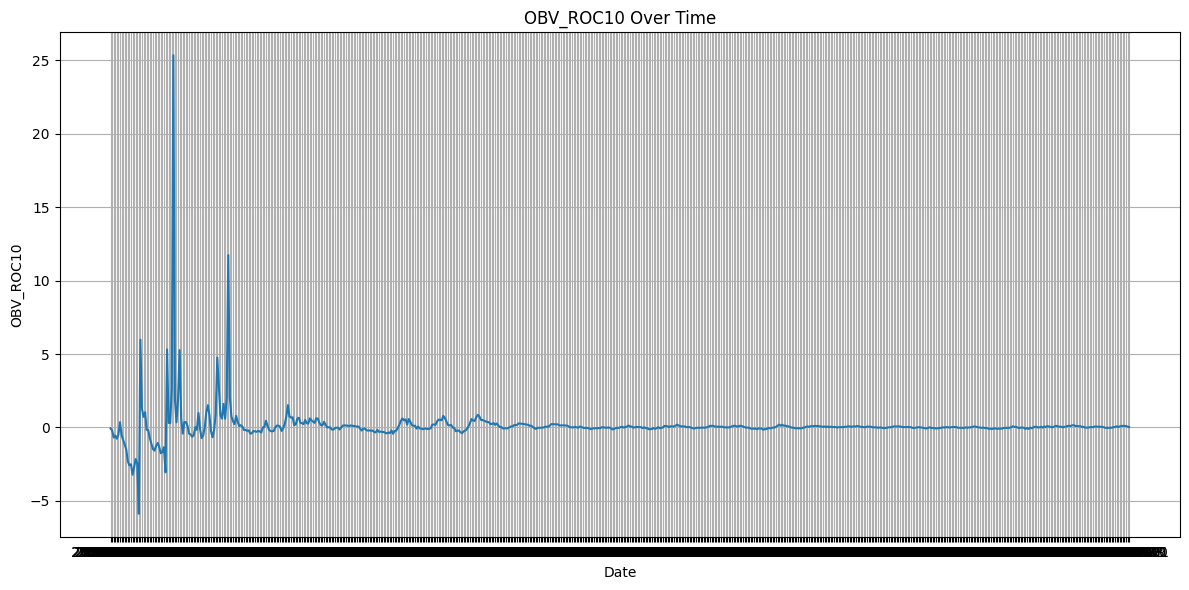

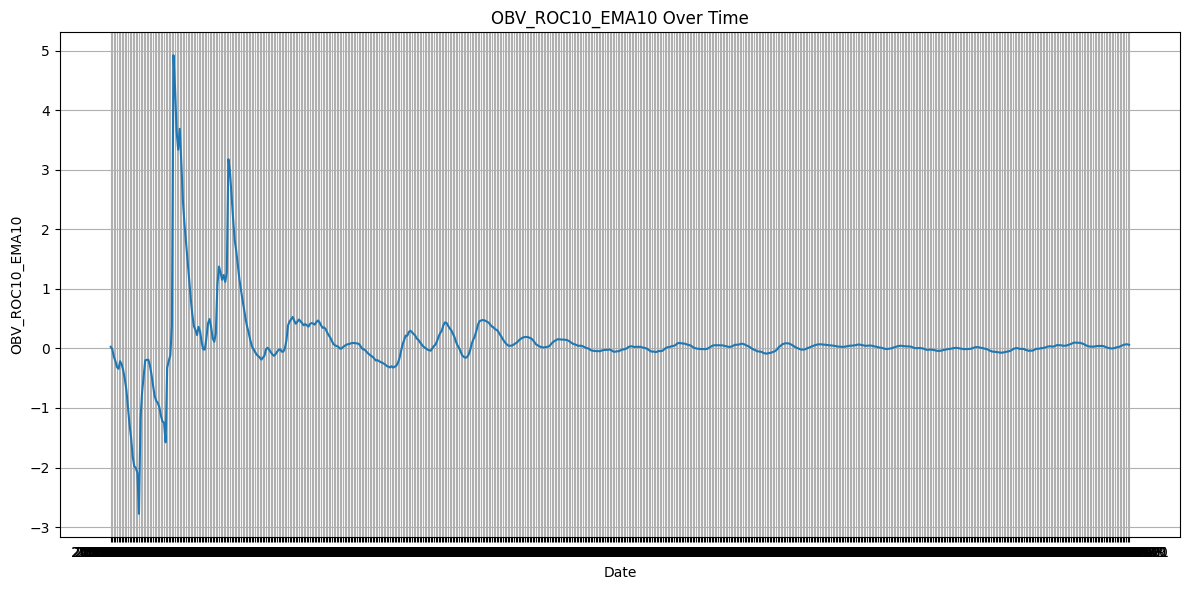

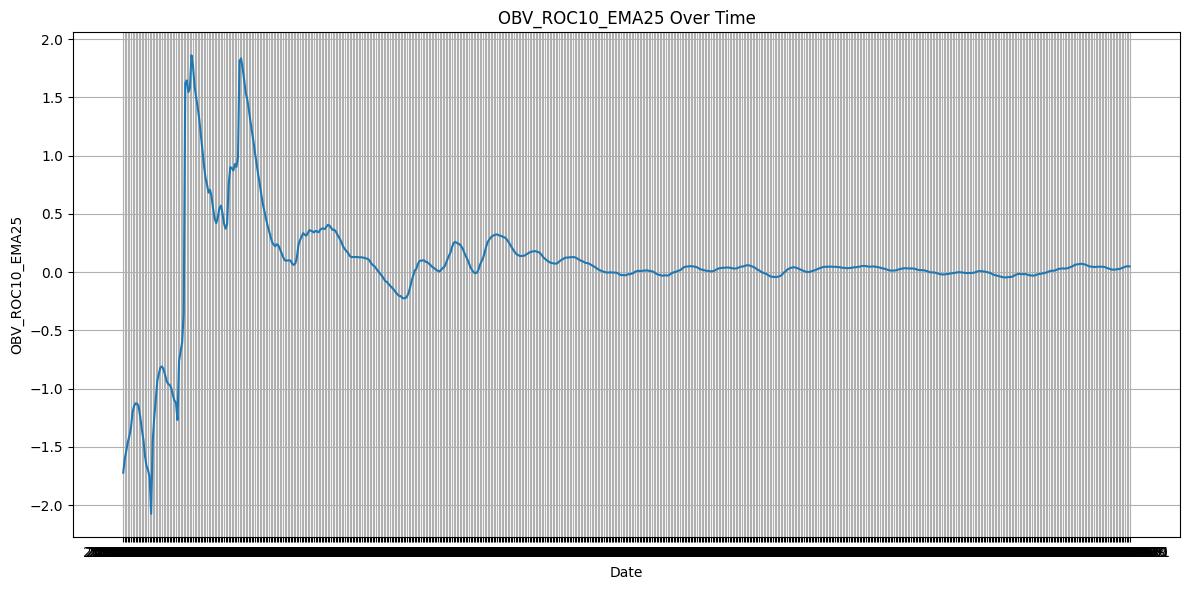

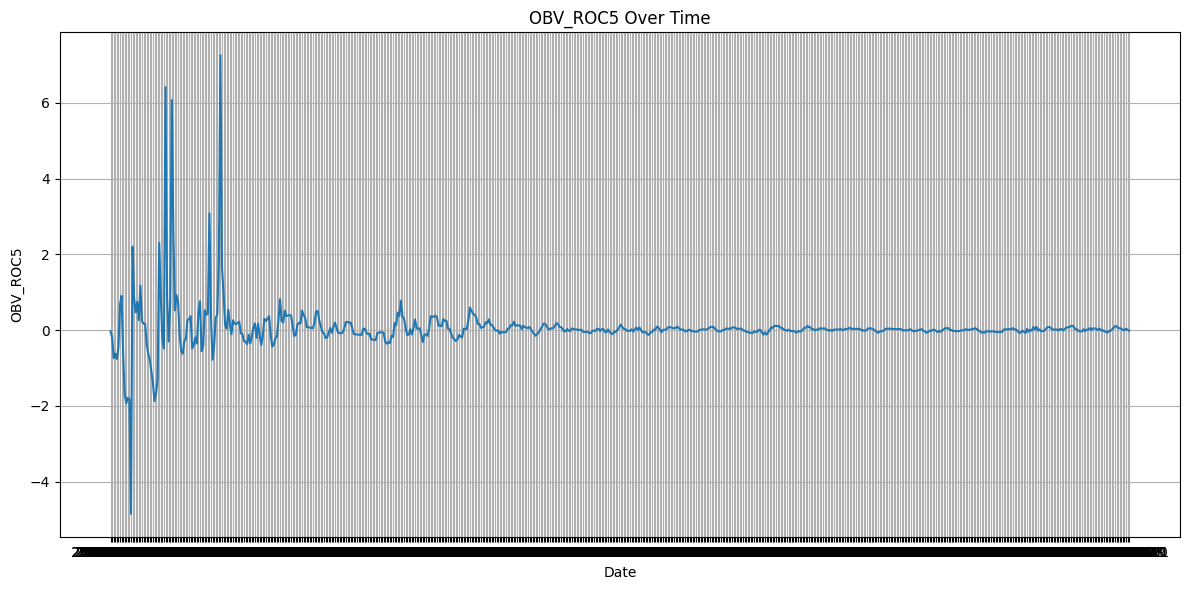

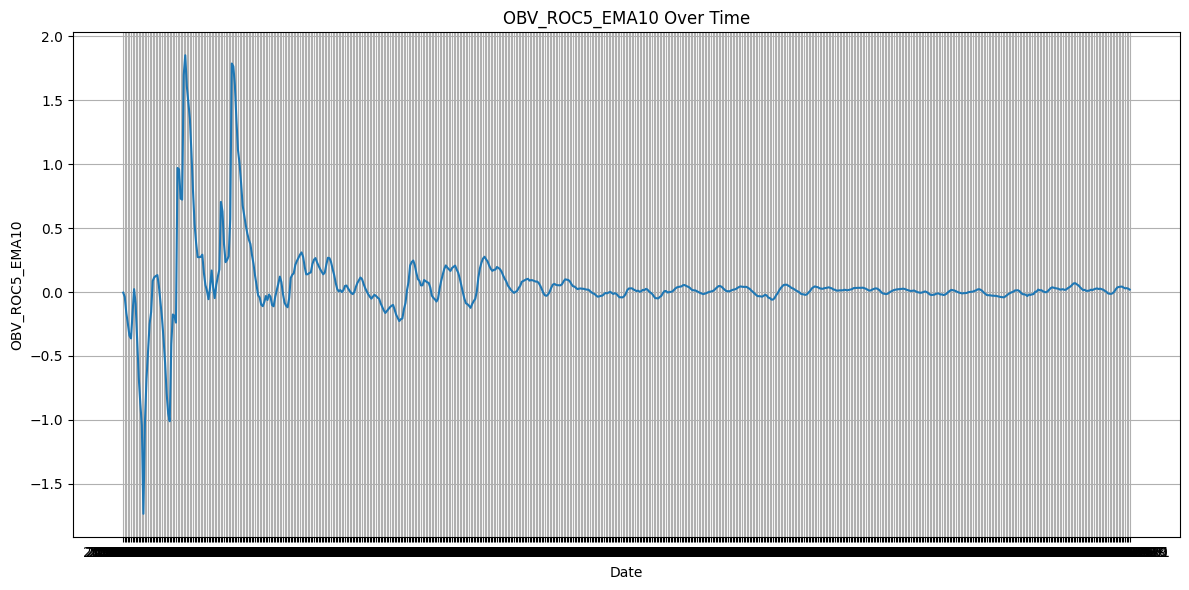

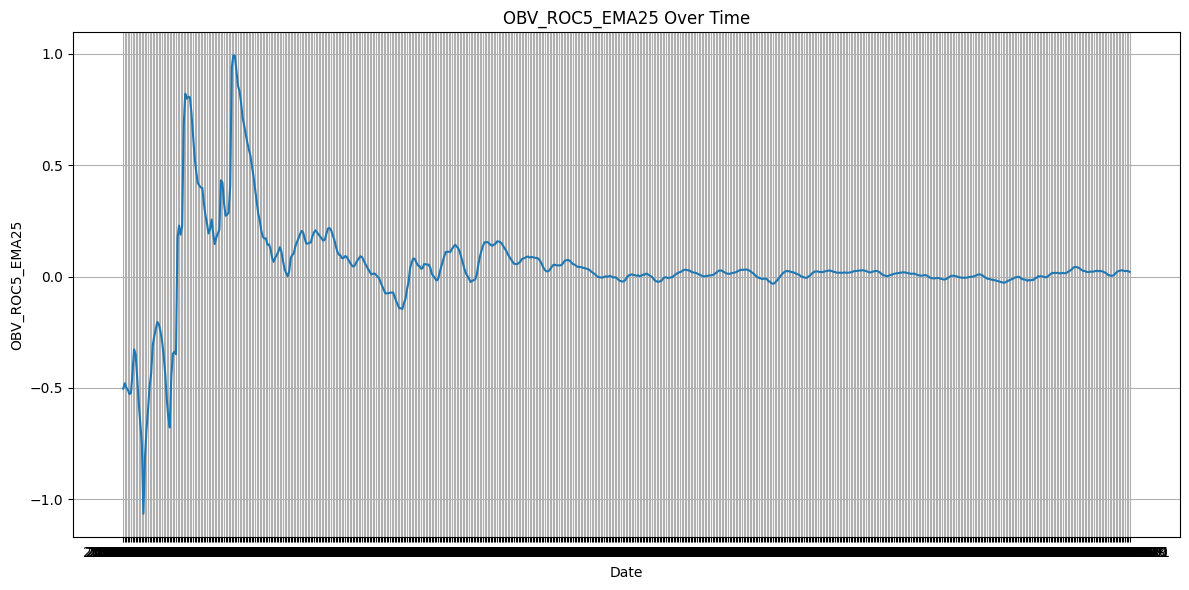

In [262]:
import matplotlib.pyplot as plt
#df = extract('QQQ', returns, lb, raw_all, windows=[10,25])
cols = [
    'VROC_10', 'VROC_10_EMA10', 'VROC_10_EMA25',
    'VROC_5', 'VROC_5_EMA10', 'VROC_5_EMA25',
    'VROC_3', 'VROC_3_EMA10', 'VROC_3_EMA25',
    'OBV_ROC10', 'OBV_ROC10_EMA10', 'OBV_ROC10_EMA25',
    'OBV_ROC5', 'OBV_ROC5_EMA10', 'OBV_ROC5_EMA25',
    'Regime_Category', 'Regime_Category_EMA10', 'Regime_Category_EMA25',
    'VIX_1_change', 'VIX_1_change_EMA10', 'VIX_1_change_EMA25',
    'VIX_5_change', 'VIX_5_change_EMA10', 'VIX_5_change_EMA25',
    'vol_5', 'vol_5_EMA10', 'vol_5_EMA25',
    'Intraday Change', 'Intraday Change_EMA10', 'Intraday Change_EMA25',
    'Vol_Ratio_100', 'Vol_Ratio_100_EMA10', 'Vol_Ratio_100_EMA25',
    'Price_Vol_Ratio_5', 'Price_Vol_Ratio_5_EMA10', 'Price_Vol_Ratio_5_EMA25',
    'ATR_7', 'ATR_7_EMA10', 'ATR_7_EMA25',
    'Vol_Ratio_10', 'Vol_Ratio_10_EMA10', 'Vol_Ratio_10_EMA25',
    'vol_25', 'vol_25_EMA10', 'vol_25_EMA25',
    'vol_10', 'vol_10_EMA10', 'vol_10_EMA25'
]


cols = [
    'OBV_ROC10', 'OBV_ROC10_EMA10', 'OBV_ROC10_EMA25',
    'OBV_ROC5', 'OBV_ROC5_EMA10', 'OBV_ROC5_EMA25',
]
for col in cols:
    try:
        plt.figure(figsize=(12, 6))
        plt.plot(df['Date'].iloc[:650].sort_index(ascending=True), df[col].iloc[:650].sort_index(ascending=True))
        plt.xlabel('Date')
        plt.ylabel(f'{col}')
        plt.title(f'{col} Over Time')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except KeyError:
        continue

In [79]:
model_dir = f'../Models/Ensemble_{ticker}'
thresh = [.5]

# Thresholds for prediction decision
upper = thresh[0]
lower = 1 - upper

# Placeholder for final predictions
combined_predictions = {}
df = extract(ticker, returns, lb, raw_all, windows=[10,25])
df = add_cyclic_seasonality(df, 
                            date_col='Date',
                            add_weekly=True,
                            add_month=True,
                            add_quarter=True,
                            add_year=True,
                            add_day_of_year=False,
                            mode='calendar',    # or 'trading' or 'both'
                            prefix='cyc_')

# Iterate through each return horizon
for r in returns:

    return_col = f"Return_{r}"

    df_ph = df.copy()

    # Create base prediction matrix with Date and Close
    pred_matrix = df_ph[['Date', 'Close']].copy()

    for arch in arch_types:
    
        selected_models = get_model_set(r)
            
        # all index-combos of length r
        for name, original_cols in selected_models.items():
            
            cols = feature_map.get((name, arch, r), original_cols)
            df_features = df_ph[cols].copy()
            df_features = df_features.replace([np.inf, -np.inf], 0)

            # XGBoost prediction
            xgb_path = os.path.join(model_dir, f"{name}_xgboost_{r}{arch}pi.pkl")
            if os.path.exists(xgb_path):
                with open(xgb_path, 'rb') as f:
                    model_xgb = pickle.load(f)
                prob_xgb = model_xgb.predict_proba(df_features)[:, 1]
                col_name_xgb = f"{name}_xgb_{r}{arch}"
                pred_matrix[col_name_xgb] = np.where(
                    prob_xgb > upper, prob_xgb,
                    np.where(prob_xgb < lower, prob_xgb - 1, 0)
                )

            # Final summed prediction across models
            pred_cols = [col for col in pred_matrix.columns if col not in ['Date', 'Close'] and not col.startswith('sum_')]
            pred_matrix[f"sum_{r}"] = pred_matrix[pred_cols].sum(axis=1)

            combined_predictions[r] = pred_matrix

aggr_df = None

for r, df_preds in combined_predictions.items():
    cols_to_merge = [col for col in df_preds.columns if col not in ['Date', 'Close']]
    df_preds_renamed = df_preds[['Date', 'Close'] + cols_to_merge].copy()

    if aggr_df is None:
        aggr_df = df_preds_renamed
    else:
        aggr_df = pd.merge(aggr_df, df_preds_renamed, on=['Date', 'Close'], how='outer')

sub_model_df = aggr_df.copy()
sub_model_df[['Date', 'Close', 'sum_2', 'sum_3', 'sum_4', 'sum_5', 'sum_8', 'sum_10',
              'sum_15', 'sum_20']].sort_index(ascending=False).head(30).round(3)

,Date,Close,sum_2,sum_3,sum_4,sum_5,sum_8,sum_10,sum_15,sum_20
1757,2025-07-29,567.260,0.615,1.813,2.865,0.790,1.801,1.891,-0.689,-0.512
1756,2025-07-28,568.140,0.639,0.803,2.824,1.857,1.797,1.839,-0.644,0.460
1755,2025-07-25,566.370,0.615,0.746,2.813,1.729,1.822,1.866,-0.662,0.461
1754,2025-07-24,565.010,0.647,-0.233,2.994,1.798,1.832,1.847,-0.507,0.540
1753,2025-07-23,563.810,1.691,1.925,1.957,2.917,1.792,1.816,-0.222,0.589
1752,2025-07-22,561.250,1.668,1.901,0.981,2.783,1.801,1.770,0.990,0.667
1751,2025-07-21,564.170,1.658,0.760,1.949,1.796,1.858,1.820,2.067,0.792
1750,2025-07-18,561.260,0.679,1.692,1.975,2.897,3.070,1.763,2.039,0.851
1749,2025-07-17,561.800,1.752,0.837,2.008,2.894,3.036,1.745,2.037,0.871
1748,2025-07-16,557.290,1.799,1.925,2.116,2.987,3.093,1.854,2.143,0.953


In [161]:
# BEFORE any loops:
feature_importance_records = []

for r in returns:
    return_col = f"Return_{r}"
    df_ph = df.copy()
    pred_matrix = df_ph[['Date','Close']].copy()

    for arch in arch_types:
        selected_models = get_model_set(r)
        
        for name, cols in selected_models.items():
            # prepare features
            df_features = df_ph[cols].replace([np.inf, -np.inf], 0)

            # load model if it exists
            xgb_path = os.path.join(model_dir, f"{name}_xgboost_{r}.pkl")
            if not os.path.exists(xgb_path):
                continue
            with open(xgb_path,'rb') as f:
                model_xgb = pickle.load(f)

            # 1) record the top-5 importances
            importances = model_xgb.feature_importances_
            feat_imp_pairs = list(zip(cols, importances))
            for feature, imp in sorted(feat_imp_pairs, key=lambda x: x[1], reverse=True)[:5]:
                feature_importance_records.append({
                    'horizon':   r,
                    'arch':      arch,
                    'model':     name,
                    'feature':   feature,
                    'importance': imp
                })

            # 2) your existing prediction code
            prob_xgb     = model_xgb.predict_proba(df_features)[:,1]
            col_name_xgb = f"{name}_xgb_{r}{arch}"
            pred_matrix[col_name_xgb] = np.where(
                prob_xgb > upper, prob_xgb,
                np.where(prob_xgb < lower, prob_xgb - 1, 0)
            )

# AFTER all loops:
fi_df = pd.DataFrame(feature_importance_records)

In [111]:
import pandas as pd

# never wrap a wide DataFrame across multiple lines
pd.set_option('display.expand_frame_repr', False)
# show all columns
pd.set_option('display.max_columns', None)
# pretend the display is super wide
pd.set_option('display.width', 10000)
       

In [63]:
horizon_dfs[2]

,Date,Close,raw_trend_fast+raw_trend_ratio_slow_25_xgb_2deep,sum_2,raw_duration_slow_10+raw_trend_moderate+raw_trend_ratio_slow_10_xgb_2deep,raw_trend_ratio_moderate_25+raw_volatility_moderate_25_xgb_2deep,raw_trend_ratio_fast_25+raw_momentum_moderate_10+raw_momentum_fast_10_xgb_2deep,raw_trend_ratio_moderate_10+raw_momentum_moderate_25_xgb_2deep,Return_2
0,2018-07-23,171.468,0.569,-0.465,-0.524,-0.552,0.575,-0.533,1
1,2018-07-24,172.175,0.565,-0.487,-0.519,-0.548,0.536,-0.520,0
2,2018-07-25,174.581,0.550,-0.610,0.505,-0.545,-0.572,-0.548,0
3,2018-07-26,171.936,0.550,-1.670,-0.514,-0.549,-0.608,-0.549,0
4,2018-07-27,169.616,0.559,-1.609,-0.508,-0.521,-0.610,-0.531,0
...,...,...,...,...,...,...,...,...,...
1754,2025-07-21,564.170,0.515,2.639,0.546,0.514,0.560,0.504,0
1755,2025-07-22,561.250,0.550,2.671,0.536,0.505,0.566,0.514,1
1756,2025-07-23,563.810,0.512,2.658,0.550,0.504,0.571,0.521,1
1757,2025-07-24,565.010,-0.506,0.588,0.549,-0.530,0.557,0.519,0


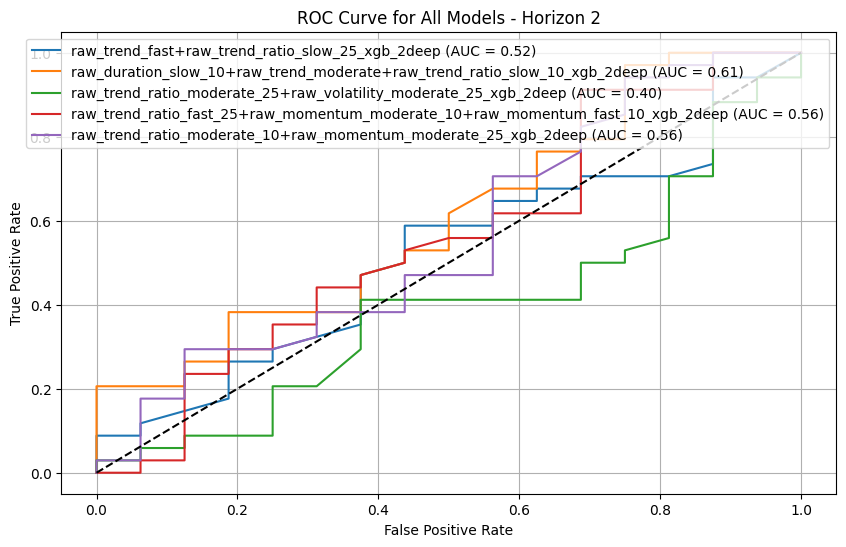

                                                                             model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0                                 raw_trend_fast+raw_trend_ratio_slow_25_xgb_2deep       34       16   66.7%   25.0%  28  14   2   6
1        raw_duration_slow_10+raw_trend_moderate+raw_trend_ratio_slow_10_xgb_2deep       34       16   73.3%   80.0%  33  12   4   1
2                 raw_trend_ratio_moderate_25+raw_volatility_moderate_25_xgb_2deep       34       16   68.0%    nan%  34  16   0   0
3  raw_trend_ratio_fast_25+raw_momentum_moderate_10+raw_momentum_fast_10_xgb_2deep       34       16   69.6%   50.0%  32  14   2   2
4                   raw_trend_ratio_moderate_10+raw_momentum_moderate_25_xgb_2deep       34       16   69.4%  100.0%  34  15   1   0
 


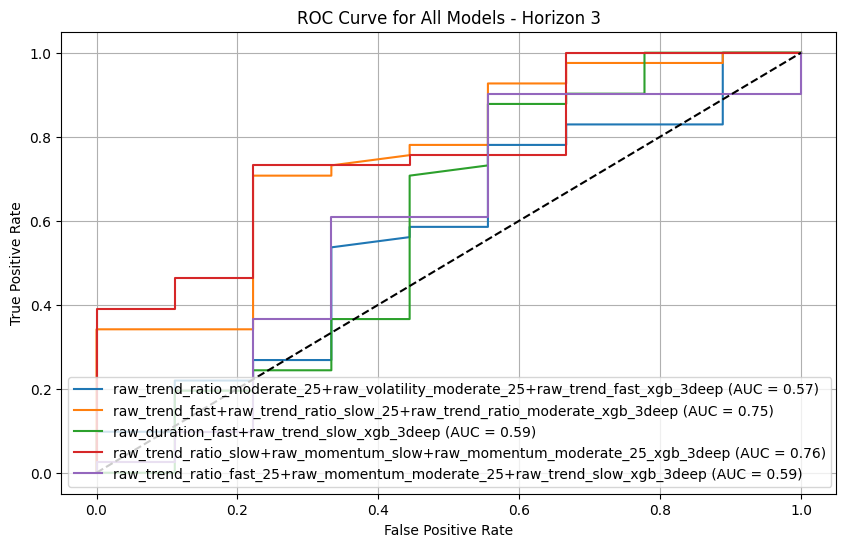

                                                                             model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0  raw_trend_ratio_moderate_25+raw_volatility_moderate_25+raw_trend_fast_xgb_3deep       41        9   84.6%   27.3%  33   6   3   8
1        raw_trend_fast+raw_trend_ratio_slow_25+raw_trend_ratio_moderate_xgb_3deep       41        9   86.8%   33.3%  33   5   4   8
2                                       raw_duration_fast+raw_trend_slow_xgb_3deep       41        9   86.0%   42.9%  37   6   3   4
3        raw_trend_ratio_slow+raw_momentum_slow+raw_momentum_moderate_25_xgb_3deep       41        9   85.0%   30.0%  34   6   3   7
4        raw_trend_ratio_fast_25+raw_momentum_moderate_25+raw_trend_slow_xgb_3deep       41        9   88.1%   50.0%  37   5   4   4
 


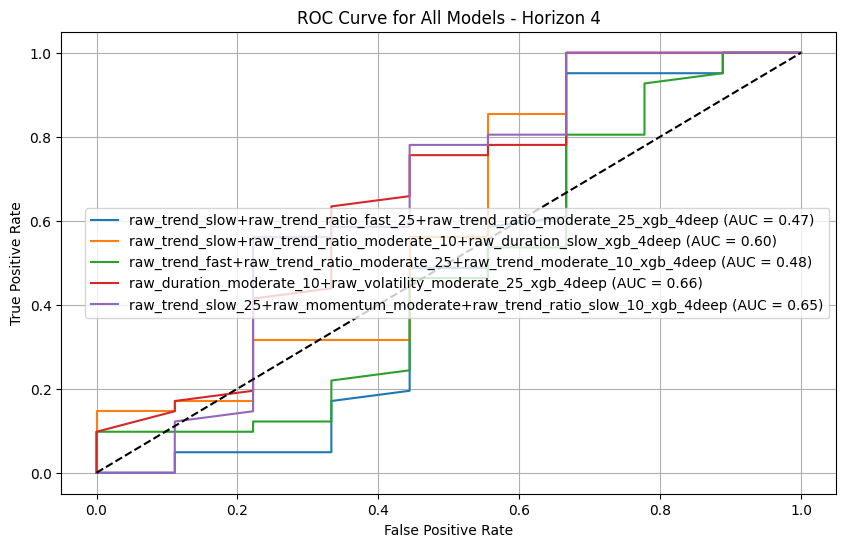

                                                                          model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0  raw_trend_slow+raw_trend_ratio_fast_25+raw_trend_ratio_moderate_25_xgb_4deep       41        9   86.4%   50.0%  38   6   3   3
1        raw_trend_slow+raw_trend_ratio_moderate_10+raw_duration_slow_xgb_4deep       41        9   86.4%   50.0%  38   6   3   3
2    raw_trend_fast+raw_trend_ratio_moderate_25+raw_trend_moderate_10_xgb_4deep       41        9   84.2%   25.0%  32   6   3   9
3                 raw_duration_moderate_10+raw_volatility_moderate_25_xgb_4deep       41        9   82.0%    nan%  41   9   0   0
4     raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_slow_10_xgb_4deep       41        9   86.4%   50.0%  38   6   3   3
 


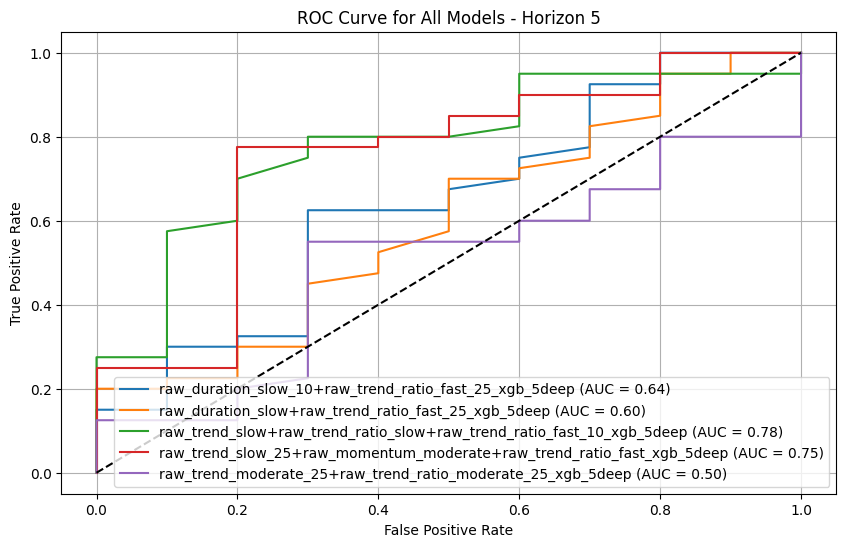

                                                                    model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0                  raw_duration_slow_10+raw_trend_ratio_fast_25_xgb_5deep       40       10   83.3%  100.0%  40   8   2   0
1                     raw_duration_slow+raw_trend_ratio_fast_25_xgb_5deep       40       10   81.2%   50.0%  39   9   1   1
2   raw_trend_slow+raw_trend_ratio_slow+raw_trend_ratio_fast_10_xgb_5deep       40       10   86.0%   57.1%  37   6   4   3
3  raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_fast_xgb_5deep       40       10   83.3%  100.0%  40   8   2   0
4             raw_trend_moderate_25+raw_trend_ratio_moderate_25_xgb_5deep       40       10   76.2%    0.0%  32  10   0   8
 


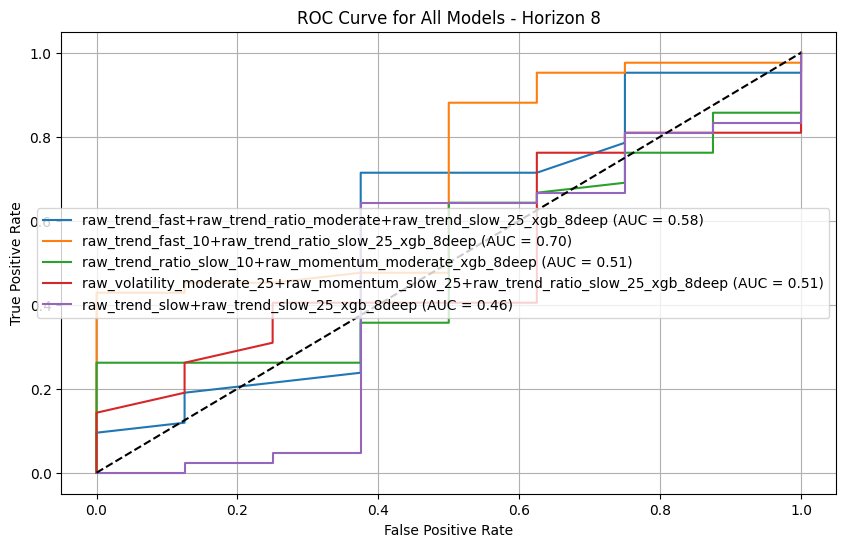

                                                                               model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0                raw_trend_fast+raw_trend_ratio_moderate+raw_trend_slow_25_xgb_8deep       42        8   84.0%    nan%  42   8   0   0
1                                raw_trend_fast_10+raw_trend_ratio_slow_25_xgb_8deep       42        8   84.0%    nan%  42   8   0   0
2                            raw_trend_ratio_slow_10+raw_momentum_moderate_xgb_8deep       42        8   84.0%    nan%  42   8   0   0
3  raw_volatility_moderate_25+raw_momentum_slow_25+raw_trend_ratio_slow_25_xgb_8deep       42        8   82.6%    0.0%  38   8   0   4
4                                         raw_trend_slow+raw_trend_slow_25_xgb_8deep       42        8   83.7%    0.0%  41   8   0   1
 


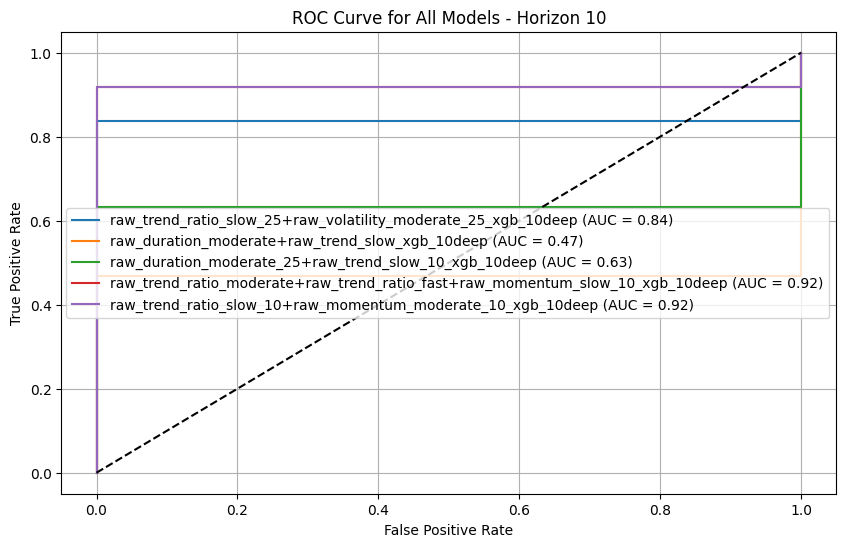

                                                                           model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0                  raw_trend_ratio_slow_25+raw_volatility_moderate_25_xgb_10deep       49        1   98.0%    0.0%  48   1   0   1
1                                raw_duration_moderate+raw_trend_slow_xgb_10deep       49        1   98.0%    nan%  49   1   0   0
2                          raw_duration_moderate_25+raw_trend_slow_10_xgb_10deep       49        1   97.9%    0.0%  46   1   0   3
3  raw_trend_ratio_moderate+raw_trend_ratio_fast+raw_momentum_slow_10_xgb_10deep       49        1   97.9%    0.0%  46   1   0   3
4                    raw_trend_ratio_slow_10+raw_momentum_moderate_10_xgb_10deep       49        1   98.0%    nan%  49   1   0   0
 


/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, 

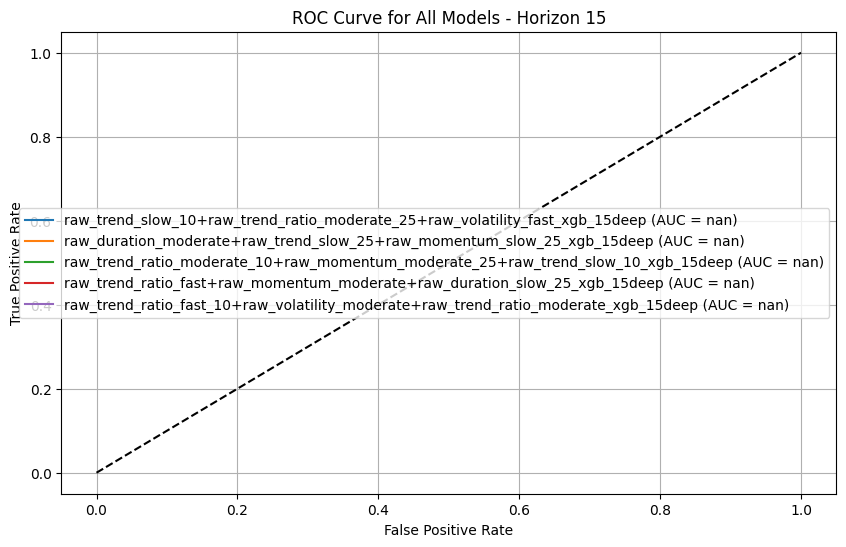

                                                                                 model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0         raw_trend_slow_10+raw_trend_ratio_moderate_25+raw_volatility_fast_xgb_15deep       50        0  100.0%     n/a  42   0   0   8
1              raw_duration_moderate+raw_trend_slow_25+raw_momentum_slow_25_xgb_15deep       50        0  100.0%     n/a  50   0   0   0
2    raw_trend_ratio_moderate_10+raw_momentum_moderate_25+raw_trend_slow_10_xgb_15deep       50        0  100.0%     n/a  50   0   0   0
3           raw_trend_ratio_fast+raw_momentum_moderate+raw_duration_slow_25_xgb_15deep       50        0  100.0%     n/a  49   0   0   1
4  raw_trend_ratio_fast_10+raw_volatility_moderate+raw_trend_ratio_moderate_xgb_15deep       50        0  100.0%     n/a  49   0   0   1
 


/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, 

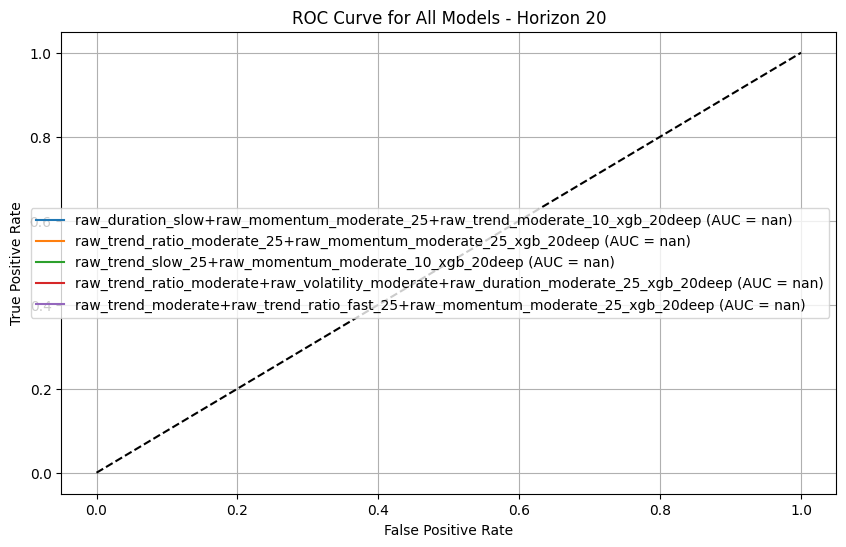

                                                                                  model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0           raw_duration_slow+raw_momentum_moderate_25+raw_trend_moderate_10_xgb_20deep       50        0  100.0%     n/a  50   0   0   0
1                       raw_trend_ratio_moderate_25+raw_momentum_moderate_25_xgb_20deep       50        0  100.0%     n/a  50   0   0   0
2                                 raw_trend_slow_25+raw_momentum_moderate_10_xgb_20deep       50        0  100.0%     n/a  47   0   0   3
3  raw_trend_ratio_moderate+raw_volatility_moderate+raw_duration_moderate_25_xgb_20deep       50        0  100.0%     n/a  49   0   0   1
4        raw_trend_moderate+raw_trend_ratio_fast_25+raw_momentum_moderate_25_xgb_20deep       50        0  100.0%     n/a  50   0   0   0
 


In [62]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)

def performance_metrics(metrics_df, returns):

    metrics_df = metrics_df.sort_index(ascending=True)

    def add_column_based_on_future_value(df, days):

        future_return = (df['Close'].shift(-days) - df['Close']) / df['Close']

        if days >= 100:
            df[f'Return_{days}'] = np.where(
                future_return > 0.001, 1,
                np.where(future_return < -0.001, 0, np.nan)
            )
        else:
            df[f'Return_{days}'] = (future_return > 0).astype(int)

        return df

    # Apply return logic for each target horizon
    for r in returns: 
        new_df = add_column_based_on_future_value(metrics_df, r)

    return new_df

performance_df = performance_metrics(sub_model_df.round(3), returns)

horizons = returns
# Dictionary to store the filtered DataFrames
horizon_dfs = {}

# Loop through each horizon
for h in horizons:
    # Collect relevant columns
    cols = ['Date', 'Close'] + [
        col for col in performance_df.columns 
        if col.endswith(f'_xgb_{h}deep') or col.endswith(f'_xgb_{h}shallow') or col == f'sum_{h}' or col == f'Return_{h}'
    ]
    
    # Create and store the filtered DataFrame
    horizon_dfs[h] = performance_df[cols].copy()

def convert_signed_to_prob(p):
    return p if p >= 0 else 1 + p

for h in horizons:
    df = horizon_dfs[h].sort_values('Date', ascending=False).iloc[h:h+50, :].copy()
    
    plt.figure(figsize=(10, 6))
    for col in df.columns:
        if f'_xgb_{h}' in col: #sum_{h}
            filtered = df[df[col] != 0]
            probs = filtered[col].apply(convert_signed_to_prob)
            targets = filtered[f'Return_{h}']
            fpr, tpr, _ = roc_curve(targets, probs)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{col} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve for All Models - Horizon {h}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()
    
    """
    # --- Calibration Curve ---
    plt.figure(figsize=(10, 6))
    for col in df.columns:
        if f'_xgb_{h}' in col:
            filtered = df[df[col] != 0]
            probs = filtered[col].apply(convert_signed_to_prob)
            targets = filtered[f'Return_{h}']
            prob_true, prob_pred = calibration_curve(targets, probs, n_bins=50)
            plt.plot(prob_pred, prob_true, marker='o', label=col)

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Calibration Curve - Horizon {h}')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Actual Frequency')
    plt.legend()
    plt.grid()
    plt.show()
    """
    

    for arch in ['deep']:
        records = []
        actual_pos = df[f'Return_{h}'].sum()
        actual_neg = len(df[f'Return_{h}']) - actual_pos
        for col in df.columns:
            if f'_xgb_{h}{arch}' in col:
                # only keep the rows that actually got a prediction
                filtered = df[df[col] != 0]
                # convert your raw score to a probability
                probs = filtered[col].apply(convert_signed_to_prob)
                # binarize at 0.5
                y_pred = (probs >= 0.5).astype(int)
                y_true = filtered[f'Return_{h}']
                
                # compute the matrix
                cm = confusion_matrix(y_true, y_pred,labels=[0,1])
                tn, fp, fn, tp = cm.ravel()
                records.append({
                    'model': col,
                    'act_pos': actual_pos,
                    'act_neg': actual_neg,
                    'pos_acc': f"{(tp/(tp + fp)):.1%}" if actual_pos>0 else "n/a",
                    'neg_acc': f"{(tn/(tn + fn)):.1%}" if actual_neg>0 else "n/a",
                    'tp': tp,
                    'fp': fp,
                    'tn': tn,
                    'fn': fn,
                })

        # make your summary table
        cm_df = pd.DataFrame(records)
        print(cm_df.to_string())
        print(' ')

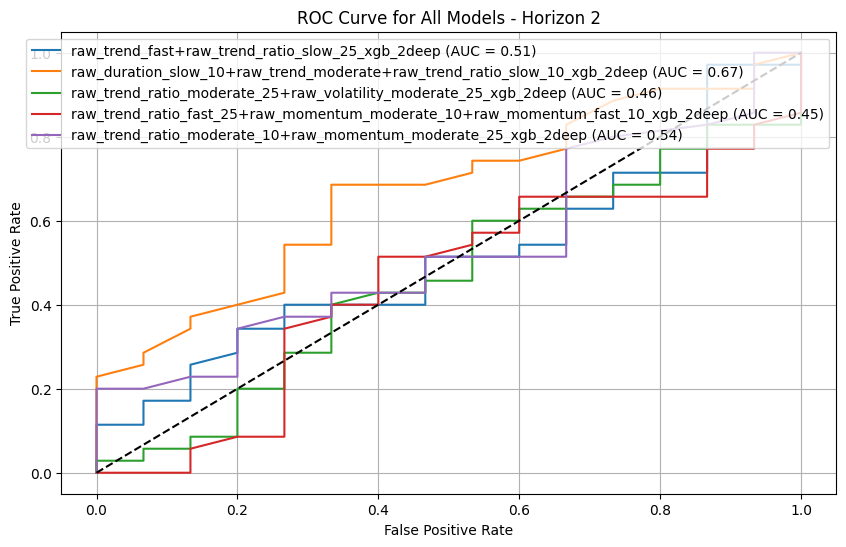

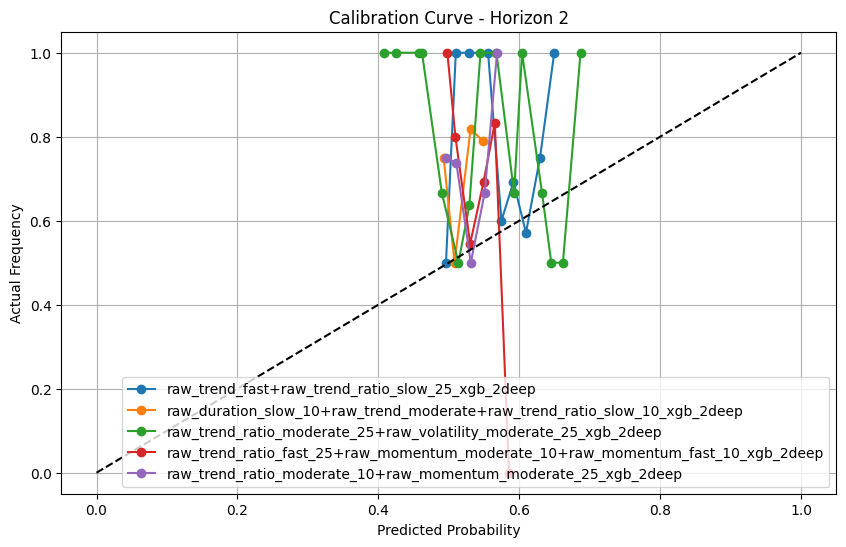

                                                                             model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0                                 raw_trend_fast+raw_trend_ratio_slow_25_xgb_2deep       35       15   71.7%   50.0%  33  13   2   2
1        raw_duration_slow_10+raw_trend_moderate+raw_trend_ratio_slow_10_xgb_2deep       35       15   69.6%   25.0%  32  14   1   3
2                 raw_trend_ratio_moderate_25+raw_volatility_moderate_25_xgb_2deep       35       15   66.7%   21.4%  24  12   3  11
3  raw_trend_ratio_fast_25+raw_momentum_moderate_10+raw_momentum_fast_10_xgb_2deep       35       15   68.8%    0.0%  33  15   0   2
4                   raw_trend_ratio_moderate_10+raw_momentum_moderate_25_xgb_2deep       35       15   70.2%   33.3%  33  14   1   2
 


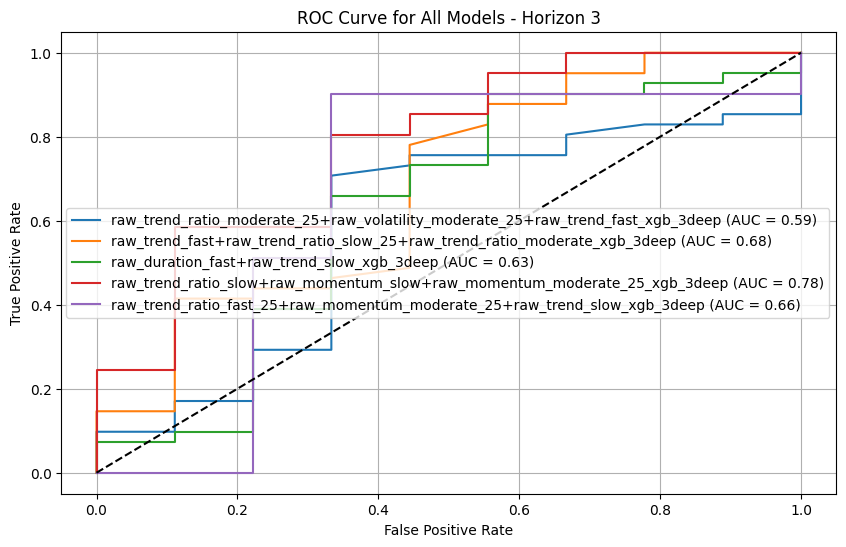

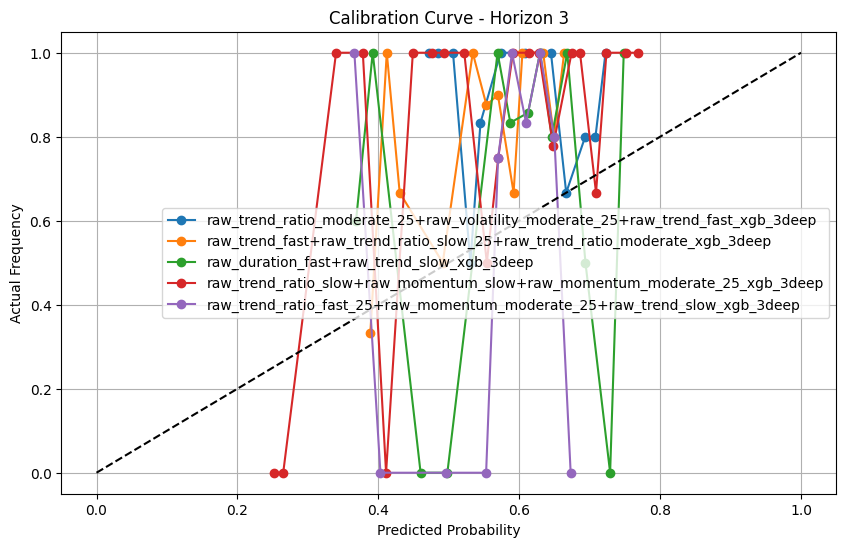

                                                                             model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0  raw_trend_ratio_moderate_25+raw_volatility_moderate_25+raw_trend_fast_xgb_3deep       41        9   80.4%    0.0%  37   9   0   4
1        raw_trend_fast+raw_trend_ratio_slow_25+raw_trend_ratio_moderate_xgb_3deep       41        9   87.8%   44.4%  36   5   4   5
2                                       raw_duration_fast+raw_trend_slow_xgb_3deep       41        9   88.1%   50.0%  37   5   4   4
3        raw_trend_ratio_slow+raw_momentum_slow+raw_momentum_moderate_25_xgb_3deep       41        9   87.8%   44.4%  36   5   4   5
4        raw_trend_ratio_fast_25+raw_momentum_moderate_25+raw_trend_slow_xgb_3deep       41        9   86.0%   42.9%  37   6   3   4
 


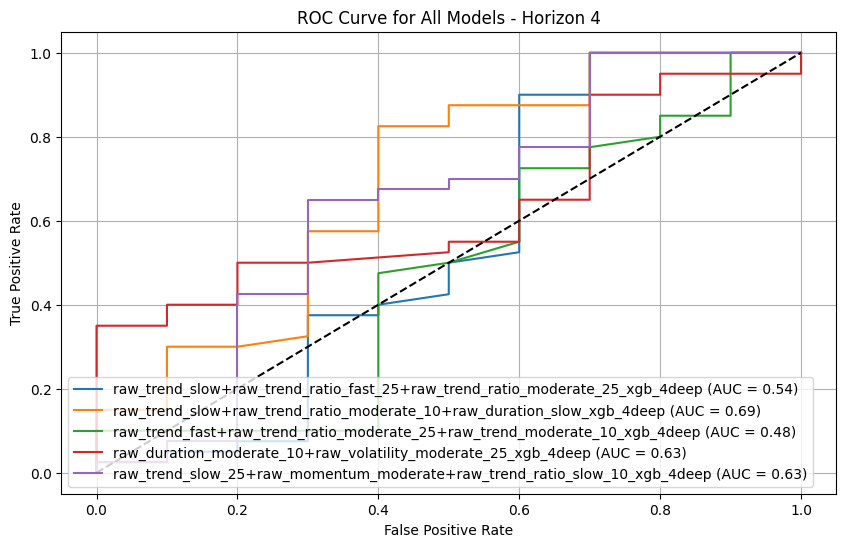

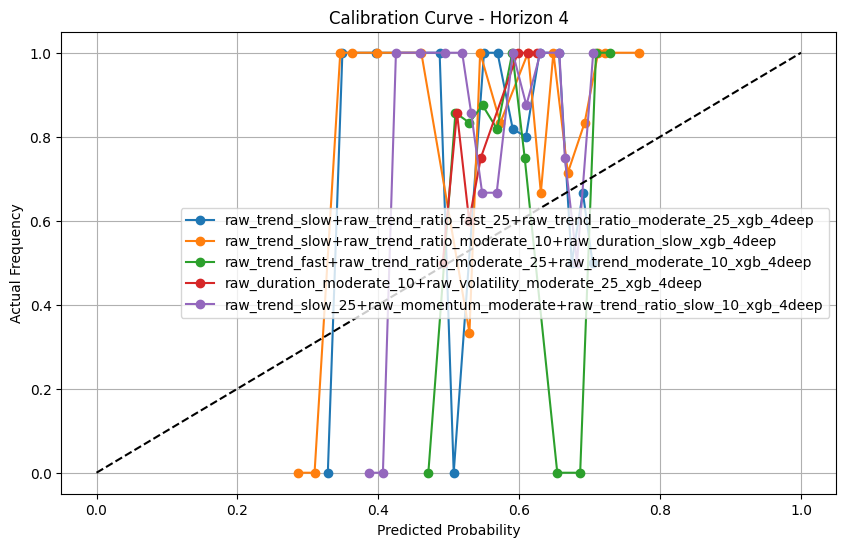

                                                                          model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0  raw_trend_slow+raw_trend_ratio_fast_25+raw_trend_ratio_moderate_25_xgb_4deep       40       10   83.7%   42.9%  36   7   3   4
1        raw_trend_slow+raw_trend_ratio_moderate_10+raw_duration_slow_xgb_4deep       40       10   83.7%   42.9%  36   7   3   4
2    raw_trend_fast+raw_trend_ratio_moderate_25+raw_trend_moderate_10_xgb_4deep       40       10   81.6%  100.0%  40   9   1   0
3                 raw_duration_moderate_10+raw_volatility_moderate_25_xgb_4deep       40       10   82.6%   50.0%  38   8   2   2
4     raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_slow_10_xgb_4deep       40       10   84.1%   50.0%  37   7   3   3
 


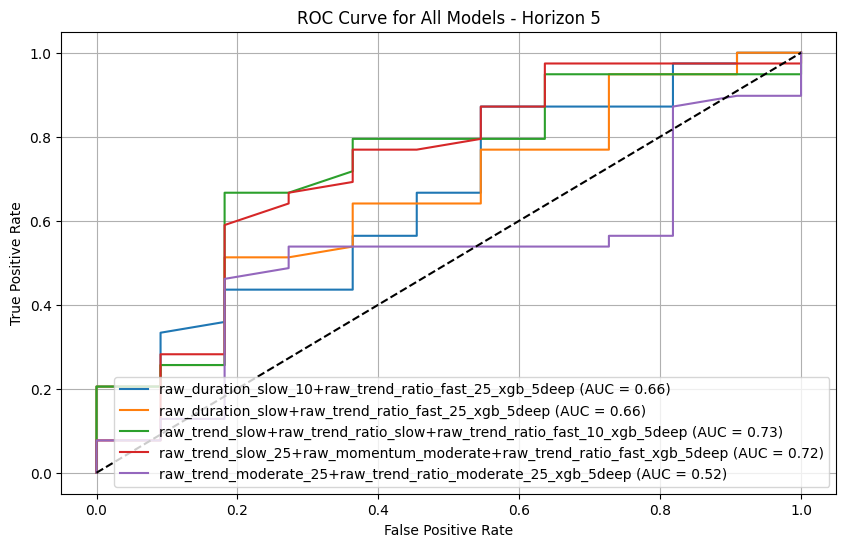

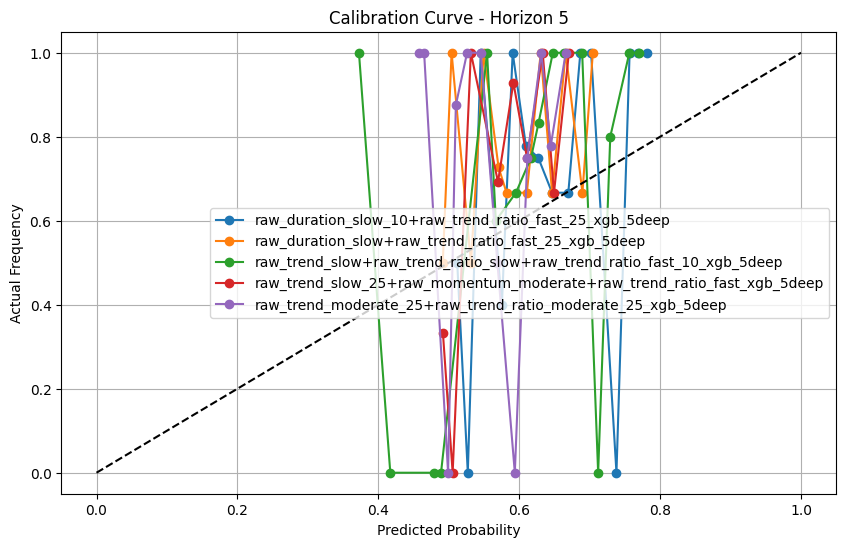

                                                                    model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0                  raw_duration_slow_10+raw_trend_ratio_fast_25_xgb_5deep       39       11   78.0%    nan%  39  11   0   0
1                     raw_duration_slow+raw_trend_ratio_fast_25_xgb_5deep       39       11   79.2%   50.0%  38  10   1   1
2   raw_trend_slow+raw_trend_ratio_slow+raw_trend_ratio_fast_10_xgb_5deep       39       11   84.1%   66.7%  37   7   4   2
3  raw_trend_slow_25+raw_momentum_moderate+raw_trend_ratio_fast_xgb_5deep       39       11   80.9%   66.7%  38   9   2   1
4             raw_trend_moderate_25+raw_trend_ratio_moderate_25_xgb_5deep       39       11   77.8%   20.0%  35  10   1   4
 


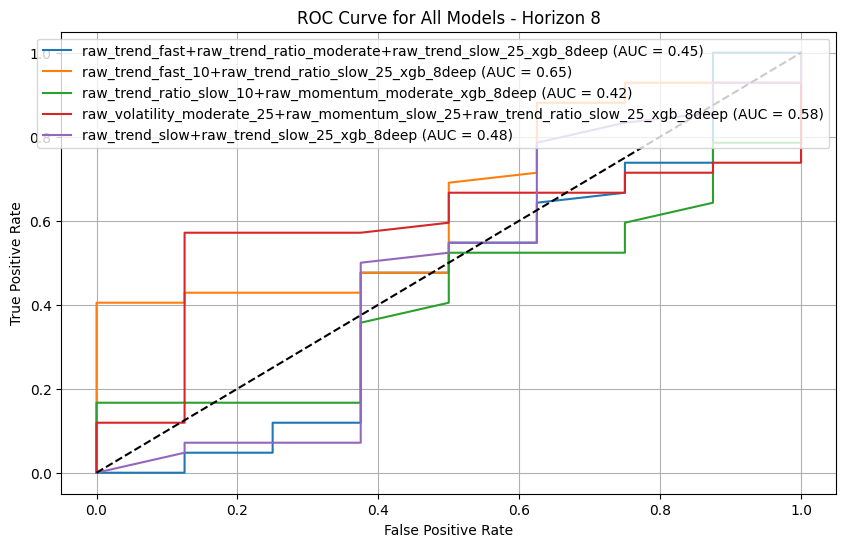

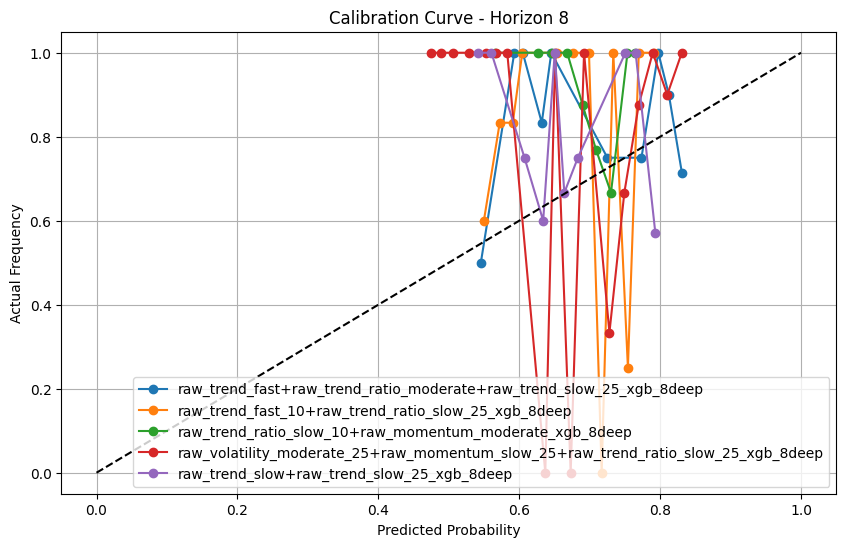

                                                                               model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0                raw_trend_fast+raw_trend_ratio_moderate+raw_trend_slow_25_xgb_8deep       42        8   84.0%    nan%  42   8   0   0
1                                raw_trend_fast_10+raw_trend_ratio_slow_25_xgb_8deep       42        8   84.0%    nan%  42   8   0   0
2                            raw_trend_ratio_slow_10+raw_momentum_moderate_xgb_8deep       42        8   84.0%    nan%  42   8   0   0
3  raw_volatility_moderate_25+raw_momentum_slow_25+raw_trend_ratio_slow_25_xgb_8deep       42        8   83.3%    0.0%  40   8   0   2
4                                         raw_trend_slow+raw_trend_slow_25_xgb_8deep       42        8   84.0%    nan%  42   8   0   0
 


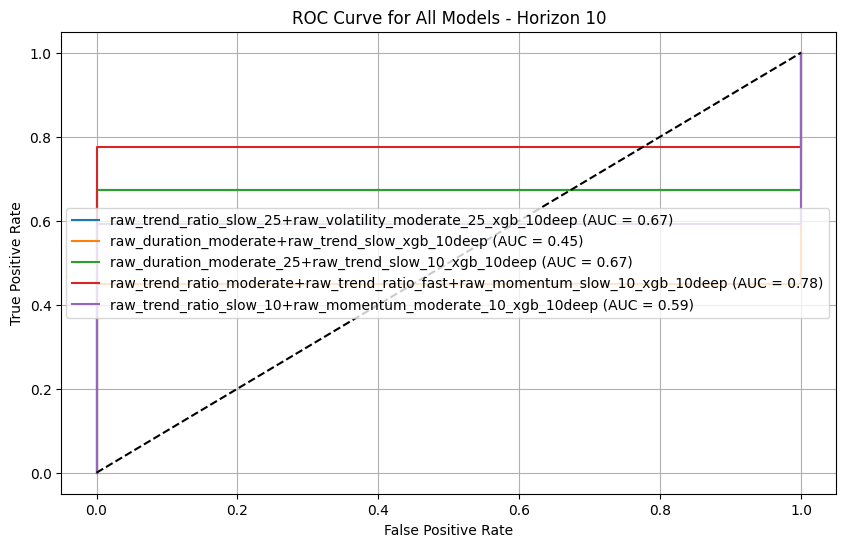

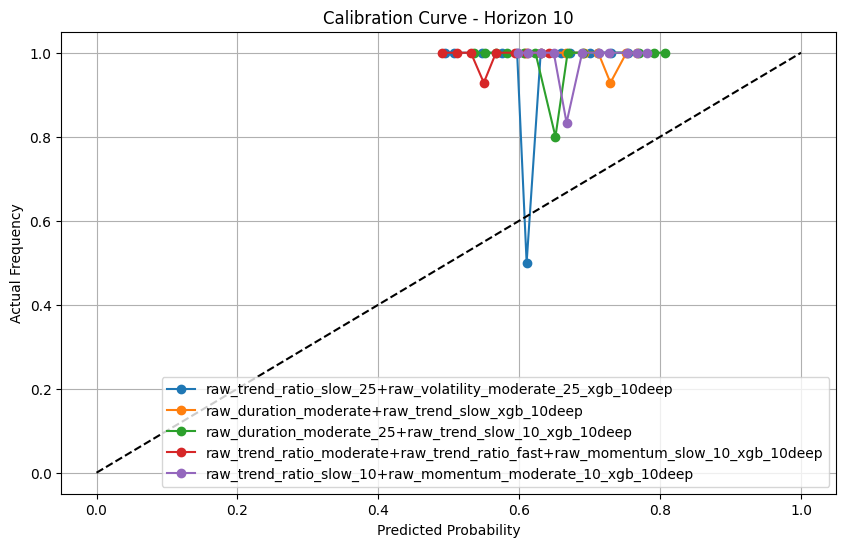

                                                                           model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0                  raw_trend_ratio_slow_25+raw_volatility_moderate_25_xgb_10deep       49        1   97.6%    0.0%  40   1   0   9
1                                raw_duration_moderate+raw_trend_slow_xgb_10deep       49        1   98.0%    nan%  49   1   0   0
2                          raw_duration_moderate_25+raw_trend_slow_10_xgb_10deep       49        1   98.0%    nan%  49   1   0   0
3  raw_trend_ratio_moderate+raw_trend_ratio_fast+raw_momentum_slow_10_xgb_10deep       49        1   97.9%    0.0%  47   1   0   2
4                    raw_trend_ratio_slow_10+raw_momentum_moderate_10_xgb_10deep       49        1   98.0%    nan%  49   1   0   0
 


/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, 

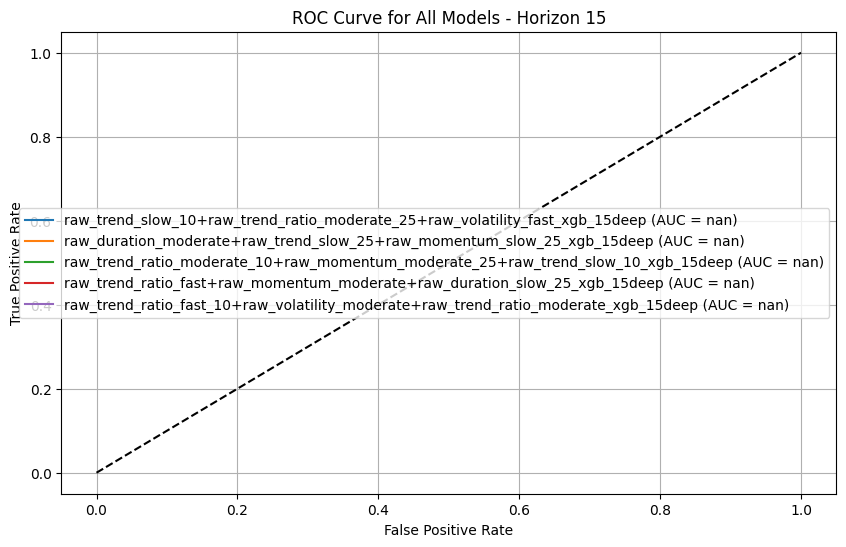

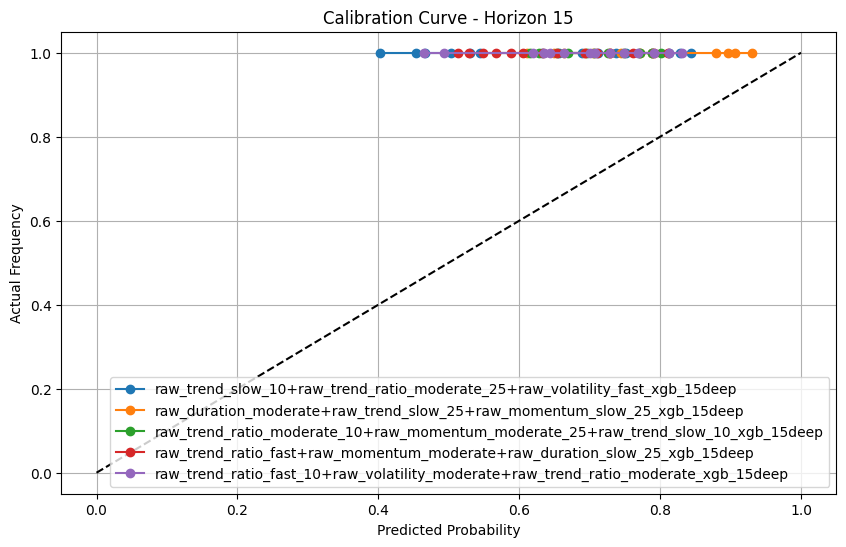

                                                                                 model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0         raw_trend_slow_10+raw_trend_ratio_moderate_25+raw_volatility_fast_xgb_15deep       50        0  100.0%     n/a  47   0   0   3
1              raw_duration_moderate+raw_trend_slow_25+raw_momentum_slow_25_xgb_15deep       50        0  100.0%     n/a  50   0   0   0
2    raw_trend_ratio_moderate_10+raw_momentum_moderate_25+raw_trend_slow_10_xgb_15deep       50        0  100.0%     n/a  50   0   0   0
3           raw_trend_ratio_fast+raw_momentum_moderate+raw_duration_slow_25_xgb_15deep       50        0  100.0%     n/a  50   0   0   0
4  raw_trend_ratio_fast_10+raw_volatility_moderate+raw_trend_ratio_moderate_xgb_15deep       50        0  100.0%     n/a  47   0   0   3
 


/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/Users/brettchase/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, 

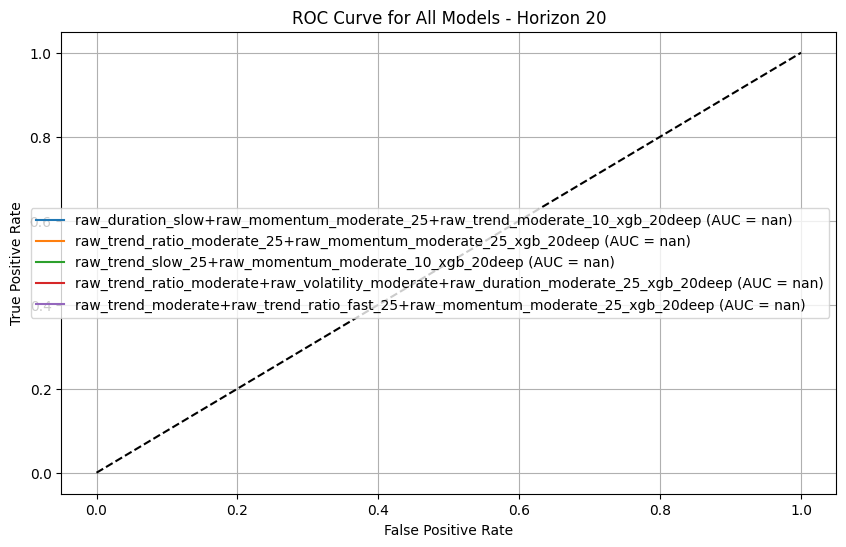

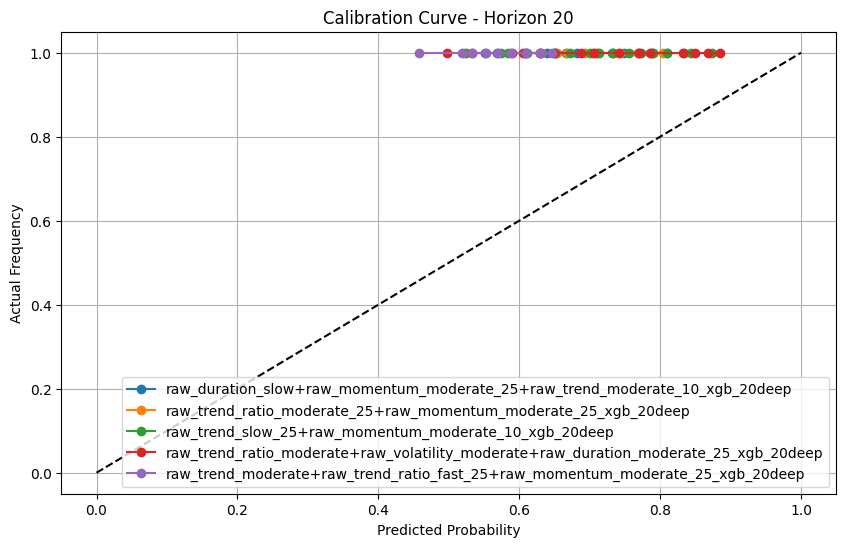

                                                                                  model  act_pos  act_neg pos_acc neg_acc  tp  fp  tn  fn
0           raw_duration_slow+raw_momentum_moderate_25+raw_trend_moderate_10_xgb_20deep       50        0  100.0%     n/a  50   0   0   0
1                       raw_trend_ratio_moderate_25+raw_momentum_moderate_25_xgb_20deep       50        0  100.0%     n/a  50   0   0   0
2                                 raw_trend_slow_25+raw_momentum_moderate_10_xgb_20deep       50        0  100.0%     n/a  50   0   0   0
3  raw_trend_ratio_moderate+raw_volatility_moderate+raw_duration_moderate_25_xgb_20deep       50        0  100.0%     n/a  49   0   0   1
4        raw_trend_moderate+raw_trend_ratio_fast_25+raw_momentum_moderate_25_xgb_20deep       50        0  100.0%     n/a  49   0   0   1
 


In [410]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)

def performance_metrics(metrics_df, returns):

    metrics_df = metrics_df.sort_index(ascending=True)

    def add_column_based_on_future_value(df, days):

        future_return = (df['Close'].shift(-days) - df['Close']) / df['Close']

        if days >= 100:
            df[f'Return_{days}'] = np.where(
                future_return > 0.001, 1,
                np.where(future_return < -0.001, 0, np.nan)
            )
        else:
            df[f'Return_{days}'] = (future_return > 0).astype(int)

        return df

    # Apply return logic for each target horizon
    for r in returns: 
        new_df = add_column_based_on_future_value(metrics_df, r)

    return new_df

performance_df = performance_metrics(sub_model_df.round(3), returns)

horizons = returns
# Dictionary to store the filtered DataFrames
horizon_dfs = {}

# Loop through each horizon
for h in horizons:
    # Collect relevant columns
    cols = ['Date', 'Close'] + [
        col for col in performance_df.columns 
        if col.endswith(f'_xgb_{h}deep') or col.endswith(f'_xgb_{h}shallow') or col == f'sum_{h}' or col == f'Return_{h}'
    ]
    
    # Create and store the filtered DataFrame
    horizon_dfs[h] = performance_df[cols].copy()

def convert_signed_to_prob(p):
    return p if p >= 0 else 1 + p

for h in horizons:
    df = horizon_dfs[h].sort_values('Date', ascending=False).iloc[h:h+50, :].copy()
    
    plt.figure(figsize=(10, 6))
    for col in df.columns:
        if f'_xgb_{h}' in col: #sum_{h}
            filtered = df[df[col] != 0]
            probs = filtered[col].apply(convert_signed_to_prob)
            targets = filtered[f'Return_{h}']
            fpr, tpr, _ = roc_curve(targets, probs)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{col} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve for All Models - Horizon {h}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()
    
    # --- Calibration Curve ---
    plt.figure(figsize=(10, 6))
    for col in df.columns:
        if f'_xgb_{h}' in col:
            filtered = df[df[col] != 0]
            probs = filtered[col].apply(convert_signed_to_prob)
            targets = filtered[f'Return_{h}']
            prob_true, prob_pred = calibration_curve(targets, probs, n_bins=50)
            plt.plot(prob_pred, prob_true, marker='o', label=col)

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Calibration Curve - Horizon {h}')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Actual Frequency')
    plt.legend()
    plt.grid()
    plt.show()
    

    for arch in ['deep']:
        records = []
        actual_pos = df[f'Return_{h}'].sum()
        actual_neg = len(df[f'Return_{h}']) - actual_pos
        for col in df.columns:
            if f'_xgb_{h}{arch}' in col:
                # only keep the rows that actually got a prediction
                filtered = df[df[col] != 0]
                # convert your raw score to a probability
                probs = filtered[col].apply(convert_signed_to_prob)
                # binarize at 0.5
                y_pred = (probs >= 0.5).astype(int)
                y_true = filtered[f'Return_{h}']
                
                # compute the matrix
                cm = confusion_matrix(y_true, y_pred,labels=[0,1])
                tn, fp, fn, tp = cm.ravel()
                records.append({
                    'model': col,
                    'act_pos': actual_pos,
                    'act_neg': actual_neg,
                    'pos_acc': f"{(tp/(tp + fp)):.1%}" if actual_pos>0 else "n/a",
                    'neg_acc': f"{(tn/(tn + fn)):.1%}" if actual_neg>0 else "n/a",
                    'tp': tp,
                    'fp': fp,
                    'tn': tn,
                    'fn': fn,
                })

        # make your summary table
        cm_df = pd.DataFrame(records)
        print(cm_df.to_string())
        print(' ')